# SVM Classification - New Datasets (Corrosion & Irritation)

This notebook implements Support Vector Machine (SVM) classifiers for irritation prediction on temporary datasets using descriptor-based features with Optuna hyperparameter optimization and comprehensive feature selection analysis.


## 1. Import Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# RDKit imports
from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, AllChem, MACCSkeys, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Descriptors import MoleculeDescriptors as md

# Sklearn imports
from sklearn.feature_selection import SelectKBest, SelectFromModel, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

# Optimization and visualization
import shap
import optuna
from optuna.pruners import MedianPruner
from joblib import dump

from preprocessing_pipeline import create_descriptor_preprocessor

# Plotting
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
DATASETS_DIR = Path("new_datasets")
DATASETS = {
    "in_vitro_corrosion": DATASETS_DIR / "in_vitro_corrosion.csv",
    "in_vitro_irritation": DATASETS_DIR / "in_vitro_irritation.csv",
    "in_vivo_corrosion": DATASETS_DIR / "in_vivo_corrosion.csv",
}

for name, path in DATASETS.items():
    df = pd.read_csv(path)
    # Display basic information about the dataset
    print(f"\n=== {name} Dataset ===")
    print("Dataset Information:")
    print(df.info())
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

    # print class distribution according to the target variable
    print("\nClass Distribution:")
    print(df["target"].value_counts())

    # Check for duplicates
    duplicates = df.duplicated().sum()
    print(f"\nNumber of duplicate rows: {duplicates}")

    # Show duplicate rows if any
    if duplicates > 0:
        print("\nDuplicate rows:")
        print(df[df.duplicated()])


=== in_vitro_corrosion Dataset ===
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   smiles  151 non-null    object
 1   target  151 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.5+ KB
None

First 5 rows of the dataset:
                         smiles  target
0                COC1=CC=CC=C1O       1
1            CC1=CC(=C(C=C1)N)C       1
2             C1=CC=C(C=C1)CCBr       0
3                   CCCCOC(=O)N       0
4  C(CC(=O)O)[C@@H](C(=O)O)N.Cl       0

Class Distribution:
target
0    91
1    60
Name: count, dtype: int64

Number of duplicate rows: 0

=== in_vitro_irritation Dataset ===
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   smiles  209 non-null    object
 

## 2. Utility Functions


In [3]:
def molecule_from_smiles(smiles):
    """Convert SMILES string to RDKit molecule object."""
    lg = RDLogger.logger()
    lg.setLevel(RDLogger.CRITICAL)
    try:
        molecule = Chem.MolFromSmiles(smiles, sanitize=True)
        if molecule is None:
            return None, "failed"

        clean_molecule = rdMolStandardize.LargestFragmentChooser()
        molecule = clean_molecule.choose(molecule)
        Chem.SanitizeMol(molecule)
        return molecule, "succeed"
    except Exception as e:
        return None, f"error: {e}"
    finally:
        lg.setLevel(RDLogger.INFO)


def calculate_descriptors(molecule):
    """Calculate RDKit descriptors (1D/2D) for a molecule."""
    descriptor_names = [desc for desc, _ in Descriptors._descList]
    calculator = md.MolecularDescriptorCalculator(descriptor_names)
    descriptor_values = calculator.CalcDescriptors(molecule)
    return dict(zip(descriptor_names, descriptor_values))


def bitvect_to_array(bitvect):
    """Convert RDKit bit vector into a NumPy array."""
    arr = np.zeros((bitvect.GetNumBits(),), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(bitvect, arr)
    return arr


def calculate_fingerprint_families(molecule, n_bits=512, radius=2):
    """Calculate all fingerprint families used in one-by-one augmentation."""
    fps = {}

    fp_morgan = AllChem.GetMorganFingerprintAsBitVect(
        molecule, radius=radius, nBits=n_bits
    )
    fps["Morgan"] = bitvect_to_array(fp_morgan)

    fp_atompair = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(
        molecule, nBits=n_bits
    )
    fps["AtomPair"] = bitvect_to_array(fp_atompair)

    fp_torsion = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(
        molecule, nBits=n_bits
    )
    fps["Torsion"] = bitvect_to_array(fp_torsion)

    fp_rdk = Chem.RDKFingerprint(molecule, fpSize=n_bits)
    fps["RDK"] = bitvect_to_array(fp_rdk)

    fp_maccs = MACCSkeys.GenMACCSKeys(molecule)
    fps["MACCS"] = bitvect_to_array(fp_maccs)

    return fps


def remove_constant_bits(X_train_fp, X_test_fp):
    """Remove only train-constant fingerprint bits and apply same drop to test."""
    constant_cols = [
        col for col in X_train_fp.columns if X_train_fp[col].nunique(dropna=False) <= 1
    ]

    if constant_cols:
        X_train_fp = X_train_fp.drop(columns=constant_cols)
        X_test_fp = X_test_fp.drop(columns=constant_cols)

    return X_train_fp, X_test_fp, constant_cols


def clean_svm_params(best_params):
    """Clean Optuna SVM params before model construction."""
    params_clean = best_params.copy()
    if "gamma_choice" in params_clean:
        gamma_choice = params_clean.pop("gamma_choice")
        if gamma_choice != "value":
            params_clean["gamma"] = gamma_choice
        elif "gamma" not in params_clean:
            params_clean["gamma"] = "scale"

    if params_clean.get("kernel", "rbf") != "poly":
        params_clean.pop("degree", None)
        params_clean.pop("coef0", None)

    return params_clean


def compute_binary_metrics(y_true, y_pred, y_proba):
    """Compute a robust binary-metrics dictionary for one split."""
    if len(np.unique(y_true)) < 2:
        roc_auc = np.nan
    else:
        roc_auc = roc_auc_score(y_true, y_proba)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
    }


def evaluate_binary_classifier(model, X_train, y_train, X_test, y_test):
    """Evaluate model on train and test splits and return predictions/probabilities."""
    y_pred_train = model.predict(X_train)
    y_proba_train = model.predict_proba(X_train)[:, 1]

    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    train_metrics = compute_binary_metrics(y_train, y_pred_train, y_proba_train)
    test_metrics = compute_binary_metrics(y_test, y_pred_test, y_proba_test)

    return {
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "y_pred_train": y_pred_train,
        "y_proba_train": y_proba_train,
        "y_pred_test": y_pred_test,
        "y_proba_test": y_proba_test,
    }


def compute_oof_train_predictions(
    X_train_raw,
    y_train,
    method,
    best_k,
    params_clean,
    calibration_method="sigmoid",
    n_splits=5,
):
    """Compute honest out-of-fold train predictions for descriptor-based models."""
    y_train_arr = np.asarray(y_train)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    y_pred_oof = np.zeros(len(y_train_arr), dtype=int)
    y_proba_oof = np.zeros(len(y_train_arr), dtype=float)

    calibration_cv = StratifiedKFold(
        n_splits=3, shuffle=True, random_state=RANDOM_STATE
    )

    for train_idx, val_idx in cv.split(X_train_raw, y_train_arr):
        if hasattr(X_train_raw, "iloc"):
            X_fold_train_raw = X_train_raw.iloc[train_idx]
            X_fold_val_raw = X_train_raw.iloc[val_idx]
        else:
            X_fold_train_raw = X_train_raw[train_idx]
            X_fold_val_raw = X_train_raw[val_idx]

        y_fold_train = y_train_arr[train_idx]

        descriptor_preprocessor = make_descriptor_preprocessor()
        X_fold_train = descriptor_preprocessor.fit_transform(X_fold_train_raw)
        X_fold_val = descriptor_preprocessor.transform(X_fold_val_raw)

        fold_scores = compute_feature_scores(method, X_fold_train, y_fold_train)
        selector, fixed_columns = build_feature_selector(
            method=method,
            k=best_k,
            n_features=X_fold_train.shape[1],
            feature_scores=fold_scores,
        )

        X_fold_train_sel = selector.fit_transform(X_fold_train, y_fold_train)
        X_fold_val_sel = selector.transform(X_fold_val)

        base_svm = SVC(
            **params_clean,
            probability=False,
            random_state=RANDOM_STATE,
        )
        model = CalibratedClassifierCV(
            base_svm,
            method=calibration_method,
            cv=calibration_cv,
        )
        model.fit(X_fold_train_sel, y_fold_train)

        y_pred_oof[val_idx] = model.predict(X_fold_val_sel)
        y_proba_oof[val_idx] = model.predict_proba(X_fold_val_sel)[:, 1]

    return {
        "train_metrics": compute_binary_metrics(y_train_arr, y_pred_oof, y_proba_oof),
        "y_pred_train": y_pred_oof,
        "y_proba_train": y_proba_oof,
    }


def compute_oof_train_predictions_fixed_matrix(
    X_train,
    y_train,
    params_clean,
    calibration_method="sigmoid",
    n_splits=5,
):
    """Compute honest out-of-fold train predictions for already-prepared feature matrices."""
    y_train_arr = np.asarray(y_train)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    y_pred_oof = np.zeros(len(y_train_arr), dtype=int)
    y_proba_oof = np.zeros(len(y_train_arr), dtype=float)

    calibration_cv = StratifiedKFold(
        n_splits=3, shuffle=True, random_state=RANDOM_STATE
    )

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        if hasattr(X_train, "iloc"):
            X_fold_train = X_train.iloc[train_idx]
            X_fold_val = X_train.iloc[val_idx]
        else:
            X_fold_train = X_train[train_idx]
            X_fold_val = X_train[val_idx]

        y_fold_train = y_train_arr[train_idx]

        base_svm = SVC(
            **params_clean,
            probability=False,
            random_state=RANDOM_STATE,
        )
        model = CalibratedClassifierCV(
            base_svm,
            method=calibration_method,
            cv=calibration_cv,
        )
        model.fit(X_fold_train, y_fold_train)

        y_pred_oof[val_idx] = model.predict(X_fold_val)
        y_proba_oof[val_idx] = model.predict_proba(X_fold_val)[:, 1]

    return {
        "train_metrics": compute_binary_metrics(y_train_arr, y_pred_oof, y_proba_oof),
        "y_pred_train": y_pred_oof,
        "y_proba_train": y_proba_oof,
    }


print("✓ Utility functions defined")

✓ Utility functions defined


## 3. Data Loading & Preprocessing


In [4]:
# Preprocessing parameters
SIMILARITY_THRESHOLD = 0.80  # Near-constant feature removal (descriptors only)
CORRELATION_THRESHOLD = 0.70  # Feature correlation threshold (descriptors only)
IQR_FACTOR = 1.5  # Outlier clipping factor (descriptors only)
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.2  # Fraction of train+val used as validation split
RANDOM_STATE = 42

# Fingerprint parameters
FINGERPRINT_BITS = 512
FINGERPRINT_RADIUS = 2
FINGERPRINT_FAMILIES = ["AtomPair", "Morgan", "Torsion", "RDK", "MACCS"]

# Container for processed datasets
processed_data = {}

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"Processing: {dataset_name}")
    print(f"{'='*60}")

    # Load dataset
    df = pd.read_csv(dataset_path)
    print(f"Loaded dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    # Remove duplicates
    initial_count = len(df)
    df = df.drop_duplicates()
    print(f"Removed {initial_count - len(df)} duplicate rows")

    # Identify SMILES and target columns (assuming standard naming)
    smiles_col = None
    target_col = None

    for col in df.columns:
        if "smiles" in col.lower() or "smi" in col.lower():
            smiles_col = col
        if "target" in col.lower() or "label" in col.lower() or "class" in col.lower():
            target_col = col

    if smiles_col is None or target_col is None:
        print("Warning: Could not auto-detect SMILES/target columns")
        print(f"Available columns: {df.columns.tolist()}")
        # Assume last column is target, first is SMILES
        smiles_col = df.columns[0]
        target_col = df.columns[-1]
        print(f"Using: SMILES={smiles_col}, Target={target_col}")

    y = df[target_col].values
    print(f"Target distribution: {np.bincount(y.astype(int))}")

    # Keep optional identifiers for per-model descriptor CSV traceability
    identifier_patterns = (
        "compound_id",
        "compoundid",
        "cas",
        "smiles",
        "inchikey",
        "inchi",
    )
    identifier_columns = []
    for col in df.columns:
        col_lower = col.lower().strip()
        if col == target_col:
            continue
        if any(pattern in col_lower for pattern in identifier_patterns):
            identifier_columns.append(col)

    if smiles_col not in identifier_columns:
        identifier_columns.append(smiles_col)

    identifier_columns = list(dict.fromkeys(identifier_columns))
    print(f"Identifier columns for export: {identifier_columns}")

    # Extract descriptors and fingerprints from SMILES
    print("\nExtracting RDKit descriptors and fingerprints...")
    descriptor_rows = []
    metadata_rows = []
    fingerprint_rows = {family: [] for family in FINGERPRINT_FAMILIES}
    valid_indices = []

    for idx, smiles in enumerate(df[smiles_col].astype(str)):
        molecule, state = molecule_from_smiles(smiles)
        if molecule is None:
            continue

        descriptor_rows.append(calculate_descriptors(molecule))
        metadata_rows.append(
            {
                "source_index": idx,
                **{col: df.iloc[idx][col] for col in identifier_columns},
            }
        )

        fp_families = calculate_fingerprint_families(
            molecule, n_bits=FINGERPRINT_BITS, radius=FINGERPRINT_RADIUS
        )
        for family in FINGERPRINT_FAMILIES:
            fingerprint_rows[family].append(fp_families[family])
        valid_indices.append(idx)

    X_descriptors = pd.DataFrame(descriptor_rows)
    metadata_valid = pd.DataFrame(metadata_rows)
    y_valid = y[valid_indices]

    print(f"Valid molecules: {len(valid_indices)}/{len(df)}")
    print(f"Descriptor matrix shape: {X_descriptors.shape}")

    # Build fingerprint dataframes with aligned indices
    fingerprint_dataframes = {}
    for family in FINGERPRINT_FAMILIES:
        family_matrix = np.vstack(fingerprint_rows[family])
        family_columns = [
            f"fp_{family.lower()}_{i}" for i in range(family_matrix.shape[1])
        ]
        fingerprint_dataframes[family] = pd.DataFrame(
            family_matrix, columns=family_columns, index=X_descriptors.index
        )

    # Holdout test split
    (
        X_train_val_desc,
        X_test_desc,
        y_train_val,
        y_test,
        meta_train_val,
        meta_test,
    ) = train_test_split(
        X_descriptors,
        y_valid,
        metadata_valid,
        test_size=TEST_SIZE,
        stratify=y_valid,
        random_state=RANDOM_STATE,
    )

    # Validation split inside training partition (used for model selection)
    X_train_desc, X_val_desc, y_train, y_val, meta_train, meta_val = train_test_split(
        X_train_val_desc,
        y_train_val,
        meta_train_val,
        test_size=VALIDATION_SIZE,
        stratify=y_train_val,
        random_state=RANDOM_STATE,
    )

    print(
        f"Split sizes -> Train: {X_train_desc.shape[0]}, "
        f"Validation: {X_val_desc.shape[0]}, Test: {X_test_desc.shape[0]}"
    )

    # Prepare fingerprints by family: remove only train-constant bits (fit on train only)
    fp_train = {}
    fp_val = {}
    fp_test = {}
    for family in FINGERPRINT_FAMILIES:
        X_train_fp = fingerprint_dataframes[family].loc[X_train_desc.index].copy()
        X_val_fp = fingerprint_dataframes[family].loc[X_val_desc.index].copy()
        X_test_fp = fingerprint_dataframes[family].loc[X_test_desc.index].copy()

        # Drop columns that are constant in train; apply the same mask to val/test
        X_train_fp, X_val_fp, dropped_constant_cols = remove_constant_bits(
            X_train_fp, X_val_fp
        )
        if dropped_constant_cols:
            X_test_fp = X_test_fp.drop(columns=dropped_constant_cols)

        fp_train[family] = X_train_fp
        fp_val[family] = X_val_fp
        fp_test[family] = X_test_fp
        print(
            f"{family}: kept {X_train_fp.shape[1]} bits after dropping "
            f"{len(dropped_constant_cols)} constant bits"
        )

    # Store split data; descriptor preprocessing is performed fold-wise in CV and on full train in final training
    processed_data[dataset_name] = {
        "X_train": X_train_desc,
        "X_val": X_val_desc,
        "X_test": X_test_desc,
        "X_train_raw": X_train_desc.copy(),
        "X_val_raw": X_val_desc.copy(),
        "X_test_raw": X_test_desc.copy(),
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "meta_train": meta_train,
        "meta_val": meta_val,
        "meta_test": meta_test,
        "identifier_columns": identifier_columns,
        "feature_names": X_train_desc.columns.tolist(),
        "descriptor_preprocessor": None,
        "fp_train": fp_train,
        "fp_val": fp_val,
        "fp_test": fp_test,
        "best_descriptor_method": None,
    }

print(f"\n{'='*60}")
print("✓ Data preprocessing completed for all datasets")
print(f"{'='*60}")


Processing: in_vitro_corrosion
Loaded dataset shape: (151, 2)
Columns: ['smiles', 'target']
Removed 0 duplicate rows
Target distribution: [91 60]
Identifier columns for export: ['smiles']

Extracting RDKit descriptors and fingerprints...


[04:15:09] DEPRECATION WARNING: please use MorganGenerator
[04:15:09] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:09] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:09] DEPRECATION WARNING: please use MorganGenerator
[04:15:09] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:09] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:09] DEPRECATION WARNING: please use MorganGenerator
[04:15:09] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:09] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:09] DEPRECATION WARNING: please use MorganGenerator
[04:15:09] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:09] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:09] DEPRECATION WARNING: please use MorganGenerator
[04:15:09] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:09] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:09] DEPRECATION WARNING: please use Mo

Valid molecules: 151/151
Descriptor matrix shape: (151, 217)
Split sizes -> Train: 96, Validation: 24, Test: 31
AtomPair: kept 432 bits after dropping 80 constant bits
Morgan: kept 365 bits after dropping 147 constant bits
Torsion: kept 256 bits after dropping 256 constant bits
RDK: kept 512 bits after dropping 0 constant bits
MACCS: kept 135 bits after dropping 32 constant bits

Processing: in_vitro_irritation
Loaded dataset shape: (209, 2)
Columns: ['smiles', 'target']
Removed 0 duplicate rows
Target distribution: [ 93 116]
Identifier columns for export: ['smiles']

Extracting RDKit descriptors and fingerprints...


[04:15:10] DEPRECATION WARNING: please use MorganGenerator
[04:15:10] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:10] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:10] DEPRECATION WARNING: please use MorganGenerator
[04:15:10] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:10] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:10] DEPRECATION WARNING: please use MorganGenerator
[04:15:10] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:10] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:10] DEPRECATION WARNING: please use MorganGenerator
[04:15:10] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:10] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:10] DEPRECATION WARNING: please use MorganGenerator
[04:15:10] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:10] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:10] DEPRECATION WARNING: please use Mo

Valid molecules: 209/209
Descriptor matrix shape: (209, 217)
Split sizes -> Train: 133, Validation: 34, Test: 42
AtomPair: kept 376 bits after dropping 136 constant bits
Morgan: kept 378 bits after dropping 134 constant bits
Torsion: kept 229 bits after dropping 283 constant bits
RDK: kept 512 bits after dropping 0 constant bits
MACCS: kept 139 bits after dropping 28 constant bits

Processing: in_vivo_corrosion
Loaded dataset shape: (191, 2)
Columns: ['smiles', 'target']
Removed 0 duplicate rows
Target distribution: [134  57]
Identifier columns for export: ['smiles']

Extracting RDKit descriptors and fingerprints...


[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use Mo

Valid molecules: 190/191
Descriptor matrix shape: (190, 217)
Split sizes -> Train: 121, Validation: 31, Test: 38
AtomPair: kept 392 bits after dropping 120 constant bits
Morgan: kept 398 bits after dropping 114 constant bits
Torsion: kept 253 bits after dropping 259 constant bits
RDK: kept 512 bits after dropping 0 constant bits
MACCS: kept 140 bits after dropping 27 constant bits

✓ Data preprocessing completed for all datasets


[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use MorganGenerator
[04:15:11] DEPRECATION WARNING: please use AtomPairGenerator
[04:15:11] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[04:15:11] DEPRECATION WARNING: please use Mo

## 4. Feature Selection Analysis

Three complementary feature selection methods are applied to each dataset and evaluated via cross-validation.


In [5]:
def make_descriptor_preprocessor():
    """Factory to build a fresh descriptor preprocessor for each fit context."""
    return create_descriptor_preprocessor(
        similarity_threshold=SIMILARITY_THRESHOLD,
        correlation_threshold=CORRELATION_THRESHOLD,
        iqr_factor=IQR_FACTOR,
    )


def select_columns_transformer(X, columns):
    """Column picker for FunctionTransformer (expects pandas DataFrame input)."""
    return X.loc[:, columns]


def build_feature_selector(method, k, n_features, feature_scores=None):
    """Build sklearn-native selector for a method and target feature count."""
    k_use = int(min(k, n_features))

    if method == "KBest":
        return SelectKBest(score_func=f_classif, k=k_use), None

    if method == "Lasso":
        lasso = LogisticRegression(
            penalty="l1",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE,
        )
        selector = SelectFromModel(
            lasso,
            threshold=-np.inf,
            max_features=k_use,
        )
        return selector, None

    if method == "SHAP":
        if feature_scores is None:
            raise ValueError("SHAP method requires precomputed feature_scores")
        selected_columns = feature_scores.head(k_use).index.tolist()
        selector = FunctionTransformer(
            select_columns_transformer,
            kw_args={"columns": selected_columns},
            validate=False,
        )
        return selector, selected_columns

    raise ValueError(f"Unsupported method: {method}")


def get_selected_columns(method, selector, X_columns, fixed_columns=None):
    """Get selected column names from a fitted selector."""
    if method == "SHAP":
        return fixed_columns

    support_mask = selector.get_support()
    return pd.Index(X_columns)[support_mask].tolist()


def select_features_kbest(X_train, y_train):
    """KBest feature scoring using F-score."""
    selector_all = SelectKBest(score_func=f_classif, k="all")
    selector_all.fit(X_train, y_train)
    return pd.Series(selector_all.scores_, index=X_train.columns).sort_values(
        ascending=False
    )


def select_features_shap(X_train, y_train):
    """SHAP-based feature scoring with bounded sampling for runtime stability."""
    svm_quick = SVC(
        kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE
    )
    svm_quick.fit(X_train, y_train)

    max_samples = min(80, len(X_train))
    if max_samples < len(X_train):
        X_sample = X_train.sample(n=max_samples, random_state=RANDOM_STATE)
    else:
        X_sample = X_train

    explainer = shap.Explainer(lambda X: svm_quick.decision_function(X), X_sample)
    max_evals = 2 * X_sample.shape[1] + 1
    shap_values = explainer(X_sample, max_evals=max_evals)
    shap_importance = np.abs(shap_values.values).mean(axis=0)

    return pd.Series(shap_importance, index=X_sample.columns).sort_values(
        ascending=False
    )


def select_features_lasso(X_train, y_train):
    """L1-based feature scoring from logistic regression coefficients."""
    lasso = LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    lasso.fit(X_train, y_train)
    coef_abs = np.abs(lasso.coef_)
    if coef_abs.ndim > 1:
        coef_abs = coef_abs.mean(axis=0)

    return pd.Series(coef_abs, index=X_train.columns).sort_values(ascending=False)


def compute_feature_scores(method, X_train_fold, y_train_fold):
    """Compute ranking scores for the requested feature-selection method."""
    if method == "KBest":
        return select_features_kbest(X_train_fold, y_train_fold)
    if method == "SHAP":
        return select_features_shap(X_train_fold, y_train_fold)
    if method == "Lasso":
        return select_features_lasso(X_train_fold, y_train_fold)
    raise ValueError(f"Unsupported method: {method}")


def prepare_fold_cache(X_train, y_train, method):
    """Prepare fold-local preprocessed matrices and feature scores once."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fold_cache = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train_raw = X_train.iloc[train_idx]
        X_fold_val_raw = X_train.iloc[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        descriptor_preprocessor = make_descriptor_preprocessor()
        X_fold_train = descriptor_preprocessor.fit_transform(X_fold_train_raw)
        X_fold_val = descriptor_preprocessor.transform(X_fold_val_raw)

        fold_scores = compute_feature_scores(method, X_fold_train, y_fold_train)
        fold_cache.append(
            {
                "X_fold_train": X_fold_train,
                "X_fold_val": X_fold_val,
                "y_fold_train": y_fold_train,
                "y_fold_val": y_fold_val,
                "fold_scores": fold_scores,
            }
        )

    return fold_cache


def evaluate_features_cv(X_train, y_train, method, k_range):
    """Evaluate fold-safe preprocessing + feature selection + SVC over k values."""
    results = []
    selected_columns_by_k = {}

    fold_cache = prepare_fold_cache(X_train, y_train, method)

    # Compute full-train ranking once for stable selected_columns_by_k reporting.
    full_preprocessor = make_descriptor_preprocessor()
    X_train_full = full_preprocessor.fit_transform(X_train)
    full_scores = compute_feature_scores(method, X_train_full, y_train)

    for k in k_range:
        fold_metrics = []

        for fold_data in fold_cache:
            X_fold_train = fold_data["X_fold_train"]
            X_fold_val = fold_data["X_fold_val"]
            y_fold_train = fold_data["y_fold_train"]
            y_fold_val = fold_data["y_fold_val"]
            fold_scores = fold_data["fold_scores"]

            selector, _ = build_feature_selector(
                method=method,
                k=k,
                n_features=X_fold_train.shape[1],
                feature_scores=fold_scores,
            )

            X_fold_train_sel = selector.fit_transform(X_fold_train, y_fold_train)
            X_fold_val_sel = selector.transform(X_fold_val)

            svm = SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                random_state=RANDOM_STATE,
            )
            svm.fit(X_fold_train_sel, y_fold_train)

            y_pred = svm.predict(X_fold_val_sel)
            y_proba = svm.predict_proba(X_fold_val_sel)[:, 1]

            fold_metrics.append(
                {
                    "accuracy": accuracy_score(y_fold_val, y_pred),
                    "f1": f1_score(y_fold_val, y_pred, zero_division=0),
                    "roc_auc": roc_auc_score(y_fold_val, y_proba),
                }
            )

        selector_full, fixed_columns_full = build_feature_selector(
            method=method,
            k=k,
            n_features=X_train_full.shape[1],
            feature_scores=full_scores,
        )
        selector_full.fit(X_train_full, y_train)
        selected_columns = get_selected_columns(
            method=method,
            selector=selector_full,
            X_columns=X_train_full.columns,
            fixed_columns=fixed_columns_full,
        )

        selected_columns_by_k[int(k)] = selected_columns
        results.append(
            {
                "k": int(k),
                "accuracy": float(np.mean([m["accuracy"] for m in fold_metrics])),
                "f1": float(np.mean([m["f1"] for m in fold_metrics])),
                "roc_auc": float(np.mean([m["roc_auc"] for m in fold_metrics])),
            }
        )

    return pd.DataFrame(results), selected_columns_by_k


print("✓ Feature selection functions defined")

✓ Feature selection functions defined


## 5. Feature Selection Execution

Running feature selection for both datasets with CV performance analysis.


In [6]:
# Store feature selection results
feature_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Feature Selection: {dataset_name}")
    print(f"{'='*60}")

    X_train = data["X_train"]
    y_train = data["y_train"]

    full_preprocessor = make_descriptor_preprocessor()
    X_train_full = full_preprocessor.fit_transform(X_train)
    k_range = list(range(5, min(X_train_full.shape[1], 51), 5)) + [
        X_train_full.shape[1]
    ]

    results = {}

    # KBest
    print("\nRunning KBest (F-score)...")
    kbest_scores = compute_feature_scores("KBest", X_train_full, y_train)
    kbest_cv, kbest_selected = evaluate_features_cv(
        X_train,
        y_train,
        method="KBest",
        k_range=k_range,
    )
    results["KBest"] = {
        "scores": kbest_scores,
        "cv_results": kbest_cv,
        "selected_columns_by_k": kbest_selected,
    }
    print(
        f"Best KBest k={kbest_cv.loc[kbest_cv['roc_auc'].idxmax(), 'k']:.0f}, ROC-AUC={kbest_cv['roc_auc'].max():.3f}"
    )

    # SHAP
    print("\nRunning SHAP-based selection...")
    shap_scores = compute_feature_scores("SHAP", X_train_full, y_train)
    shap_cv, shap_selected = evaluate_features_cv(
        X_train,
        y_train,
        method="SHAP",
        k_range=k_range,
    )
    results["SHAP"] = {
        "scores": shap_scores,
        "cv_results": shap_cv,
        "selected_columns_by_k": shap_selected,
    }
    print(
        f"Best SHAP k={shap_cv.loc[shap_cv['roc_auc'].idxmax(), 'k']:.0f}, ROC-AUC={shap_cv['roc_auc'].max():.3f}"
    )

    # Lasso
    print("\nRunning Lasso (L1) selection...")
    lasso_scores = compute_feature_scores("Lasso", X_train_full, y_train)
    lasso_cv, lasso_selected = evaluate_features_cv(
        X_train,
        y_train,
        method="Lasso",
        k_range=k_range,
    )
    results["Lasso"] = {
        "scores": lasso_scores,
        "cv_results": lasso_cv,
        "selected_columns_by_k": lasso_selected,
    }
    print(
        f"Best Lasso k={lasso_cv.loc[lasso_cv['roc_auc'].idxmax(), 'k']:.0f}, ROC-AUC={lasso_cv['roc_auc'].max():.3f}"
    )

    feature_results[dataset_name] = results

print(f"\n{'='*60}")
print("✓ Feature selection completed for all methods and datasets")
print(f"{'='*60}")


Feature Selection: in_vitro_corrosion

Running KBest (F-score)...
Best KBest k=37, ROC-AUC=0.842

Running SHAP-based selection...
Best SHAP k=37, ROC-AUC=0.846

Running Lasso (L1) selection...
Best Lasso k=30, ROC-AUC=0.848

Feature Selection: in_vitro_irritation

Running KBest (F-score)...
Best KBest k=20, ROC-AUC=0.852

Running SHAP-based selection...
Best SHAP k=15, ROC-AUC=0.873

Running Lasso (L1) selection...
Best Lasso k=43, ROC-AUC=0.844

Feature Selection: in_vivo_corrosion

Running KBest (F-score)...
Best KBest k=35, ROC-AUC=0.821

Running SHAP-based selection...
Best SHAP k=15, ROC-AUC=0.829

Running Lasso (L1) selection...
Best Lasso k=30, ROC-AUC=0.822

✓ Feature selection completed for all methods and datasets


## 6. Feature Selection Visualization


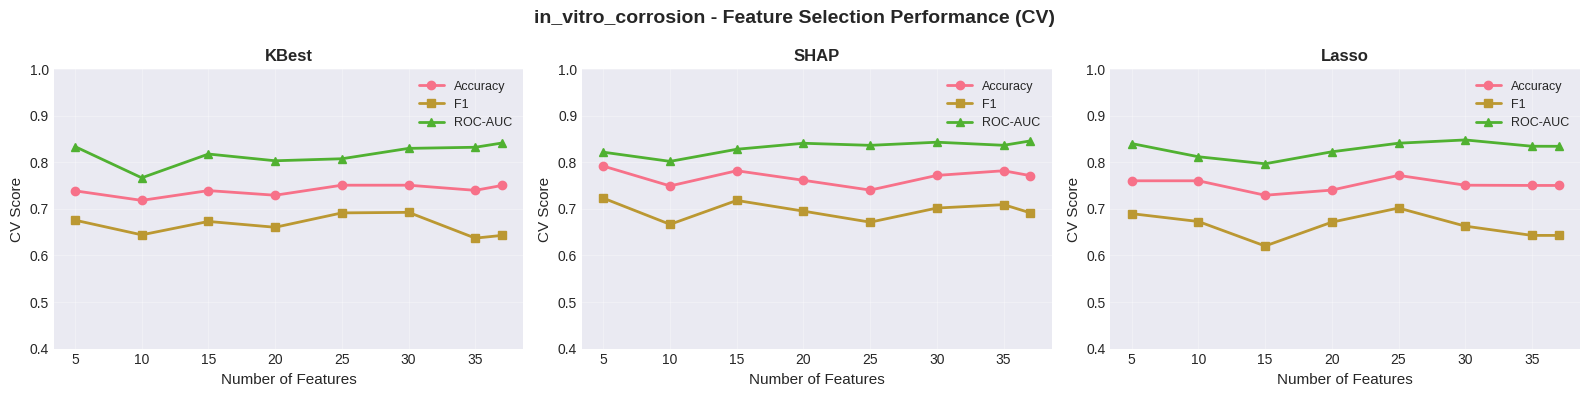

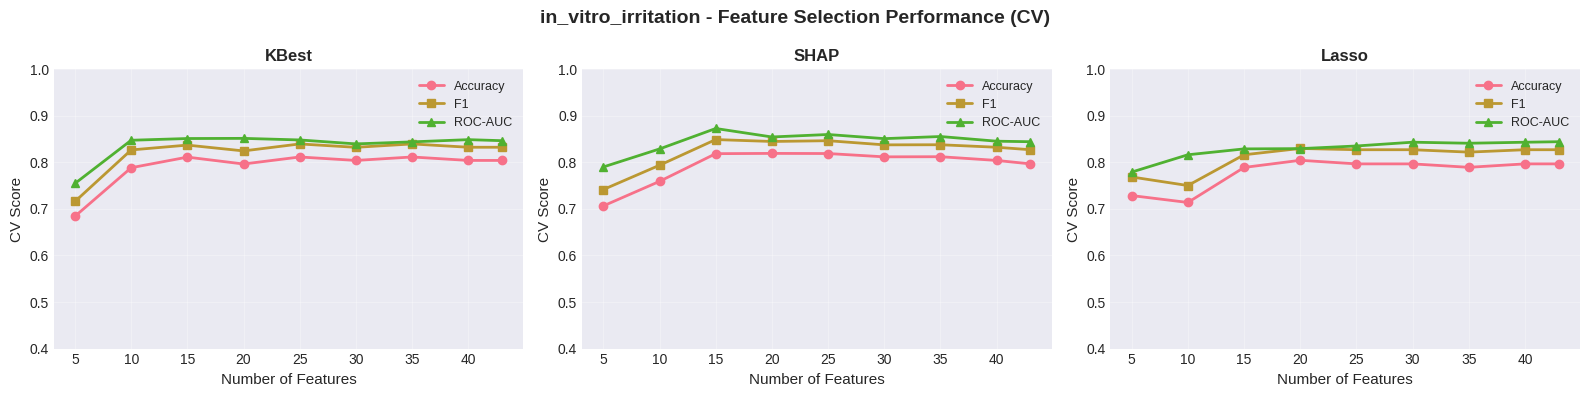

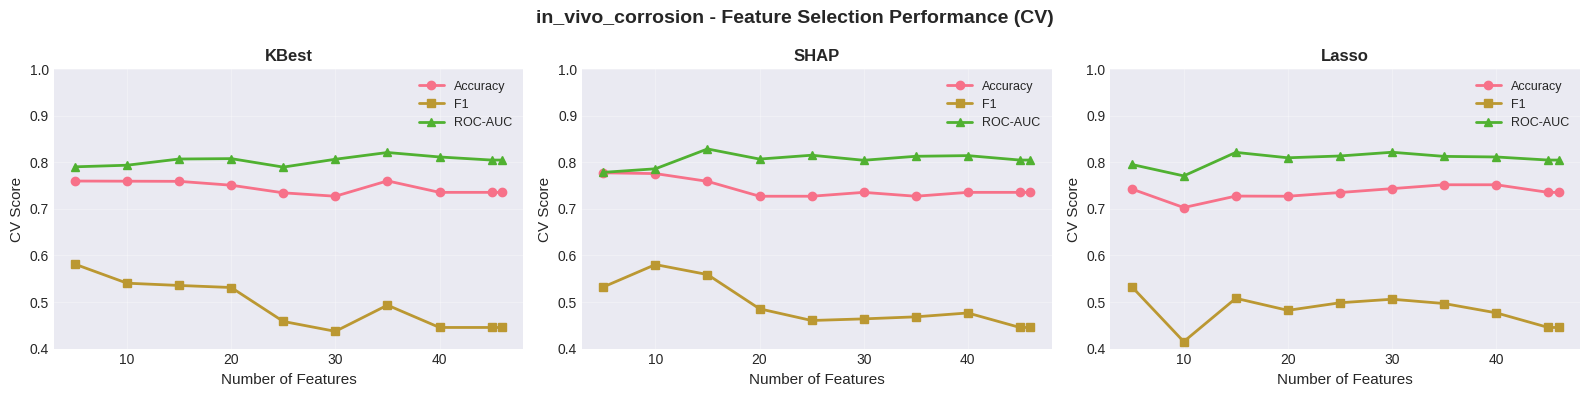

✓ Feature selection plots generated


In [7]:
for dataset_name in processed_data.keys():
    results = feature_results[dataset_name]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f"{dataset_name} - Feature Selection Performance (CV)",
        fontsize=14,
        fontweight="bold",
    )

    methods = ["KBest", "SHAP", "Lasso"]
    for idx, method in enumerate(methods):
        cv_df = results[method]["cv_results"]
        ax = axes[idx]

        ax.plot(
            cv_df["k"], cv_df["accuracy"], marker="o", label="Accuracy", linewidth=2
        )
        ax.plot(cv_df["k"], cv_df["f1"], marker="s", label="F1", linewidth=2)
        ax.plot(cv_df["k"], cv_df["roc_auc"], marker="^", label="ROC-AUC", linewidth=2)

        ax.set_xlabel("Number of Features", fontsize=11)
        ax.set_ylabel("CV Score", fontsize=11)
        ax.set_title(f"{method}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.4, 1.0])

    plt.tight_layout()
    plt.show()

print("✓ Feature selection plots generated")

## 7. Hyperparameter Optimization with Optuna


In [8]:
def objective(trial, fold_cache, method, best_k):
    """Optuna objective with fold-safe preprocessing and a narrower SVM search space."""

    C = trial.suggest_float("C", 1e-2, 1e2, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    gamma = (
        trial.suggest_float("gamma", 1e-4, 1e-1, log=True)
        if kernel == "rbf"
        else "scale"
    )
    tol = trial.suggest_float("tol", 1e-4, 1e-2, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    fold_scores = []

    for fold_data in fold_cache:
        X_fold_train = fold_data["X_fold_train"]
        X_fold_val = fold_data["X_fold_val"]
        y_fold_train = fold_data["y_fold_train"]
        y_fold_val = fold_data["y_fold_val"]
        fold_feature_scores = fold_data["fold_scores"]

        selector, _ = build_feature_selector(
            method=method,
            k=best_k,
            n_features=X_fold_train.shape[1],
            feature_scores=fold_feature_scores,
        )

        X_fold_train_sel = selector.fit_transform(X_fold_train, y_fold_train)
        X_fold_val_sel = selector.transform(X_fold_val)

        svm = SVC(
            C=C,
            kernel=kernel,
            gamma=gamma,
            tol=tol,
            max_iter=5000,
            class_weight=class_weight,
            probability=False,
            random_state=RANDOM_STATE,
        )

        svm.fit(X_fold_train_sel, y_fold_train)
        y_score = svm.decision_function(X_fold_val_sel)
        fold_scores.append(roc_auc_score(y_fold_val, y_score))

    mean_score = float(np.mean(fold_scores))
    trial.report(mean_score, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score


print("✓ Optuna objective function defined")

✓ Optuna objective function defined


In [9]:
# Optimize hyperparameters for each dataset and feature selection method
optimization_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Hyperparameter Optimization: {dataset_name}")
    print(f"{'='*60}")

    X_train = data["X_train"]
    y_train = data["y_train"]

    dataset_results = {}

    for method in ["KBest", "SHAP", "Lasso"]:
        print(f"\nOptimizing {method}...")

        cv_results = feature_results[dataset_name][method]["cv_results"]
        best_k = int(cv_results.loc[cv_results["roc_auc"].idxmax(), "k"])

        selected_columns = feature_results[dataset_name][method][
            "selected_columns_by_k"
        ][best_k]

        print(f"  Best k={best_k} ({len(selected_columns)} features selected)")

        fold_cache = prepare_fold_cache(X_train, y_train, method)

        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
        pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=5)

        study = optuna.create_study(
            direction="maximize", sampler=sampler, pruner=pruner
        )

        study.optimize(
            lambda trial: objective(
                trial,
                fold_cache=fold_cache,
                method=method,
                best_k=best_k,
            ),
            n_trials=20,
            show_progress_bar=True,
            n_jobs=-1,
        )

        best_trial = study.best_trial
        print(f"  Best CV ROC-AUC: {best_trial.value:.4f}")
        print(f"  Best hyperparameters: {best_trial.params}")

        dataset_results[method] = {
            "best_k": best_k,
            "selected_columns": selected_columns,
            "best_params": best_trial.params,
            "best_cv_score": best_trial.value,
            "study": study,
        }

    optimization_results[dataset_name] = dataset_results

print(f"\n{'='*60}")
print("✓ Hyperparameter optimization completed")
print(f"{'='*60}")


Hyperparameter Optimization: in_vitro_corrosion

Optimizing KBest...
  Best k=37 (37 features selected)


[I 2026-03-19 04:16:23,213] A new study created in memory with name: no-name-3a9f6abf-3598-4d41-9833-62dc4fc31233
Best trial: 19. Best value: 0.843885:  60%|██████    | 12/20 [00:00<00:00, 12.89it/s]

[I 2026-03-19 04:16:23,357] Trial 0 finished with value: 0.8079545454545455 and parameters: {'C': 1.137495201960348, 'kernel': 'rbf', 'gamma': 0.00019276053460700194, 'tol': 0.0010473129333236242, 'class_weight': None}. Best is trial 0 with value: 0.8079545454545455.
[I 2026-03-19 04:16:23,403] Trial 2 finished with value: 0.8033008658008658 and parameters: {'C': 0.017702858708820445, 'kernel': 'rbf', 'gamma': 0.0017164362812522405, 'tol': 0.0005813486114130789, 'class_weight': None}. Best is trial 0 with value: 0.8079545454545455.
[I 2026-03-19 04:16:23,433] Trial 3 finished with value: 0.8224296536796537 and parameters: {'C': 1.6132830895919696, 'kernel': 'rbf', 'gamma': 0.025584408620586453, 'tol': 0.004571107317930368, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.8224296536796537.
[I 2026-03-19 04:16:23,438] Trial 11 finished with value: 0.8066017316017315 and parameters: {'C': 0.8703608298172099, 'kernel': 'linear', 'tol': 0.00014121438751352145, 'class_weight': 'bal

Best trial: 19. Best value: 0.843885: 100%|██████████| 20/20 [00:00<00:00, 46.45it/s]


[I 2026-03-19 04:16:23,522] Trial 12 finished with value: 0.8136363636363637 and parameters: {'C': 26.442434192327106, 'kernel': 'rbf', 'gamma': 0.06087197489431648, 'tol': 0.001386748125839847, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.8358766233766234.
[I 2026-03-19 04:16:23,524] Trial 14 finished with value: 0.8061147186147186 and parameters: {'C': 78.49209358126026, 'kernel': 'linear', 'tol': 0.00039835323455063564, 'class_weight': None}. Best is trial 5 with value: 0.8358766233766234.
[I 2026-03-19 04:16:23,527] Trial 15 finished with value: 0.8189664502164502 and parameters: {'C': 2.221588211951223, 'kernel': 'rbf', 'gamma': 0.04600292664472755, 'tol': 0.00046364887052689714, 'class_weight': None}. Best is trial 5 with value: 0.8358766233766234.
[I 2026-03-19 04:16:23,591] Trial 16 finished with value: 0.8317099567099568 and parameters: {'C': 0.0662704532315714, 'kernel': 'linear', 'tol': 0.006748533778666227, 'class_weight': None}. Best is trial 5 with value: 0.

...

[I 2026-03-19 04:17:10,587] Trial 3 finished with value: 0.8650603991596638 and parameters: {'C': 43.20478024358323, 'kernel': 'rbf', 'gamma': 0.0023355521459405225, 'tol': 0.00489058154728308, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.8650603991596638.
[I 2026-03-19 04:17:10,595] Trial 0 finished with value: 0.8378282563025209 and parameters: {'C': 0.20093468205394524, 'kernel': 'linear', 'tol': 0.0008446692392086419, 'class_weight': None}. Best is trial 3 with value: 0.8650603991596638.
[I 2026-03-19 04:17:10,614] Trial 5 finished with value: 0.8680147058823529 and parameters: {'C': 0.0536038190563209, 'kernel': 'linear', 'tol': 0.00023165153461993465, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.8680147058823529.
[I 2026-03-19 04:17:10,617] Trial 4 finished with value: 0.8642331932773109 and parameters: {'C': 0.026512791808702373, 'kernel': 'linear', 'tol': 0.0035321350025289216, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.86801470588235

[I 2026-03-19 04:17:11,451] A new study created in memory with name: no-name-f005c948-f3fe-4a8e-950a-cb380877d8d0
Best trial: 5. Best value: 0.838682:  25%|██▌       | 5/20 [00:00<00:01,  9.57it/s]

[I 2026-03-19 04:17:11,642] Trial 6 finished with value: 0.8261160714285716 and parameters: {'C': 0.010414702447955282, 'kernel': 'rbf', 'gamma': 0.0029964521773604893, 'tol': 0.00034902493228146375, 'class_weight': 'balanced'}. Best is trial 6 with value: 0.8261160714285716.
[I 2026-03-19 04:17:11,689] Trial 5 finished with value: 0.8386817226890756 and parameters: {'C': 0.013561877143614154, 'kernel': 'linear', 'tol': 0.0010471256769433324, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.8386817226890756.
[I 2026-03-19 04:17:11,718] Trial 2 finished with value: 0.7819459033613445 and parameters: {'C': 0.19634564996451478, 'kernel': 'rbf', 'gamma': 0.07321436854500817, 'tol': 0.002050853682532367, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.8386817226890756.
[I 2026-03-19 04:17:11,739] Trial 8 finished with value: 0.753374474789916 and parameters: {'C': 76.42121147915996, 'kernel': 'rbf', 'gamma': 0.08967237791401429, 'tol': 0.009064556878447178, 'class_weigh

Best trial: 5. Best value: 0.838682: 100%|██████████| 20/20 [00:00<00:00, 44.35it/s]

[I 2026-03-19 04:17:11,770] Trial 9 finished with value: 0.8340730042016806 and parameters: {'C': 0.03868440159587555, 'kernel': 'rbf', 'gamma': 0.00014233772259536836, 'tol': 0.0005145778490073661, 'class_weight': None}. Best is trial 5 with value: 0.8386817226890756.
[I 2026-03-19 04:17:11,774] Trial 11 finished with value: 0.7760898109243697 and parameters: {'C': 2.408410813160602, 'kernel': 'linear', 'tol': 0.0005955200279999679, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.8386817226890756.
[I 2026-03-19 04:17:11,778] Trial 4 finished with value: 0.8153623949579831 and parameters: {'C': 0.059152446142574505, 'kernel': 'linear', 'tol': 0.0002340027279252045, 'class_weight': 'balanced'}. Best is trial 5 with value: 0.8386817226890756.
[I 2026-03-19 04:17:11,780] Trial 7 finished with value: 0.7735688025210083 and parameters: {'C': 4.953661358761307, 'kernel': 'linear', 'tol': 0.00047974915745724095, 'class_weight': None}. Best is trial 5 with value: 0.8386817226890756.

## 8. Train Final Models & Evaluation


In [10]:
# Train final models with optimal hyperparameters
final_models = {}
evaluation_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Training Final Models: {dataset_name}")
    print(f"{'='*60}")

    X_train_raw = data.get("X_train_raw", data["X_train"])
    X_val_raw = data.get("X_val_raw", data.get("X_val"))
    X_test_raw = data.get("X_test_raw", data["X_test"])
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]

    # Fit descriptor preprocessing once on the full train split for final model training.
    descriptor_preprocessor = make_descriptor_preprocessor()
    X_train = descriptor_preprocessor.fit_transform(X_train_raw)
    X_val = descriptor_preprocessor.transform(X_val_raw)
    X_test = descriptor_preprocessor.transform(X_test_raw)

    processed_data[dataset_name]["descriptor_preprocessor"] = descriptor_preprocessor
    processed_data[dataset_name]["X_train"] = X_train
    processed_data[dataset_name]["X_val"] = X_val
    processed_data[dataset_name]["X_test"] = X_test
    processed_data[dataset_name]["feature_names"] = X_train.columns.tolist()

    dataset_models = {}
    dataset_evals = {}

    for method in ["KBest", "SHAP", "Lasso"]:
        print(f"\nTraining {method}...")

        opt_result = optimization_results[dataset_name][method]
        best_k = int(opt_result["best_k"])
        best_params = opt_result["best_params"]
        params_clean = clean_svm_params(best_params)
        calibration_method = "sigmoid"

        feature_scores = compute_feature_scores(method, X_train, y_train)
        selector, fixed_columns = build_feature_selector(
            method=method,
            k=best_k,
            n_features=X_train.shape[1],
            feature_scores=feature_scores,
        )

        X_train_sel = selector.fit_transform(X_train, y_train)
        X_val_sel = selector.transform(X_val)
        X_test_sel = selector.transform(X_test)

        selected_columns = get_selected_columns(
            method=method,
            selector=selector,
            X_columns=X_train.columns,
            fixed_columns=fixed_columns,
        )

        oof_bundle = compute_oof_train_predictions(
            X_train_raw=X_train_raw,
            y_train=y_train,
            method=method,
            best_k=best_k,
            params_clean=params_clean,
            calibration_method=calibration_method,
            n_splits=5,
        )

        calibration_cv = StratifiedKFold(
            n_splits=3, shuffle=True, random_state=RANDOM_STATE
        )
        base_svm = SVC(
            **params_clean,
            probability=False,
            random_state=RANDOM_STATE,
        )
        final_model = CalibratedClassifierCV(
            base_svm,
            method=calibration_method,
            cv=calibration_cv,
        )
        final_model.fit(X_train_sel, y_train)

        y_pred_val = final_model.predict(X_val_sel)
        y_proba_val = final_model.predict_proba(X_val_sel)[:, 1]
        val_metrics = compute_binary_metrics(y_val, y_pred_val, y_proba_val)

        y_pred_test = final_model.predict(X_test_sel)
        y_proba_test = final_model.predict_proba(X_test_sel)[:, 1]
        test_metrics = compute_binary_metrics(y_test, y_pred_test, y_proba_test)
        train_metrics = oof_bundle["train_metrics"]

        print(f"  OOF Train Accuracy: {train_metrics['Accuracy']:.3f}")
        print(f"  OOF Train ROC-AUC: {train_metrics['ROC-AUC']:.3f}")
        print(f"  Validation ROC-AUC: {val_metrics['ROC-AUC']:.3f}")
        print(f"  Test Accuracy: {test_metrics['Accuracy']:.3f}")
        print(f"  Test F1: {test_metrics['F1']:.3f}")
        print(f"  Test ROC-AUC: {test_metrics['ROC-AUC']:.3f}")

        dataset_models[method] = final_model
        dataset_evals[method] = {
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics,
            "metrics": test_metrics,
            "y_pred_train": oof_bundle["y_pred_train"],
            "y_proba_train": oof_bundle["y_proba_train"],
            "y_pred_val": y_pred_val,
            "y_proba_val": y_proba_val,
            "y_pred_test": y_pred_test,
            "y_proba_test": y_proba_test,
            "y_pred": y_pred_test,
            "y_proba": y_proba_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
            "X_test": pd.DataFrame(
                X_test_sel, index=X_test.index, columns=selected_columns
            ),
            "feature_names": selected_columns,
            "selector": selector,
            "optuna_best_params": best_params,
            "optuna_clean_params": params_clean,
            "calibration_method": calibration_method,
            "train_metric_label": "OOF_train",
        }

    final_models[dataset_name] = dataset_models
    evaluation_results[dataset_name] = dataset_evals

print(f"\n{'='*60}")
print("✓ Final models trained and evaluated")
print(f"{'='*60}")


Training Final Models: in_vitro_corrosion

Training KBest...
  OOF Train Accuracy: 0.771
  OOF Train ROC-AUC: 0.822
  Validation ROC-AUC: 0.871
  Test Accuracy: 0.710
  Test F1: 0.609
  Test ROC-AUC: 0.798

Training SHAP...
  OOF Train Accuracy: 0.771
  OOF Train ROC-AUC: 0.792
  Validation ROC-AUC: 0.857
  Test Accuracy: 0.710
  Test F1: 0.609
  Test ROC-AUC: 0.772

Training Lasso...
  OOF Train Accuracy: 0.792
  OOF Train ROC-AUC: 0.860
  Validation ROC-AUC: 0.893
  Test Accuracy: 0.774
  Test F1: 0.667
  Test ROC-AUC: 0.846

Training Final Models: in_vitro_irritation

Training KBest...
  OOF Train Accuracy: 0.820
  OOF Train ROC-AUC: 0.850
  Validation ROC-AUC: 0.835
  Test Accuracy: 0.690
  Test F1: 0.755
  Test ROC-AUC: 0.757

Training SHAP...
  OOF Train Accuracy: 0.789
  OOF Train ROC-AUC: 0.861
  Validation ROC-AUC: 0.754
  Test Accuracy: 0.762
  Test F1: 0.800
  Test ROC-AUC: 0.787

Training Lasso...
  OOF Train Accuracy: 0.789
  OOF Train ROC-AUC: 0.852
  Validation ROC-AUC:

## 8B. Fingerprint Augmentation on Best Descriptor Model

For each dataset, we pick the best descriptor-only method by ROC-AUC and then add one fingerprint family at a time.

Rules enforced:

- Descriptor feature selection remains unchanged (KBest/SHAP/Lasso only on descriptors).
- Fingerprint bits are not feature-selected.
- Only train-constant fingerprint bits are removed.


In [11]:
# Fingerprint augmentation: descriptors + one fingerprint family at a time

fingerprint_variant_models = {}
fingerprint_variant_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Fingerprint Augmentation: {dataset_name}")
    print(f"{'='*60}")

    X_train_desc = data["X_train"]
    X_val_desc = data["X_val"]
    X_test_desc = data["X_test"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]

    best_method = max(
        ["KBest", "SHAP", "Lasso"],
        key=lambda method: evaluation_results[dataset_name][method]
        .get("val_metrics", {})
        .get("ROC-AUC", -np.inf),
    )
    processed_data[dataset_name]["best_descriptor_method"] = best_method
    opt_result = optimization_results[dataset_name][best_method]

    selected_columns = evaluation_results[dataset_name][best_method]["feature_names"]
    params_clean = clean_svm_params(opt_result["best_params"])
    calibration_method = "sigmoid"
    calibration_cv = StratifiedKFold(
        n_splits=3, shuffle=True, random_state=RANDOM_STATE
    )

    available_selected = [c for c in selected_columns if c in X_train_desc.columns]
    if not available_selected:
        available_selected = list(X_train_desc.columns)
        print(
            "Warning: selected columns not found in current descriptors, using all descriptor columns."
        )

    X_train_best_desc = X_train_desc.loc[:, available_selected]
    X_val_best_desc = X_val_desc.loc[:, available_selected]
    X_test_best_desc = X_test_desc.loc[:, available_selected]

    print(f"Best descriptor method (validation-selected): {best_method}")
    print(f"Selected descriptor features used: {X_train_best_desc.shape[1]}")

    dataset_models = {}
    dataset_results = {}

    oof_baseline = compute_oof_train_predictions_fixed_matrix(
        X_train_best_desc,
        y_train,
        params_clean,
        calibration_method=calibration_method,
        n_splits=5,
    )

    baseline_model = CalibratedClassifierCV(
        SVC(**params_clean, probability=False, random_state=RANDOM_STATE),
        method=calibration_method,
        cv=calibration_cv,
    )
    baseline_model.fit(X_train_best_desc, y_train)

    y_pred_val = baseline_model.predict(X_val_best_desc)
    y_proba_val = baseline_model.predict_proba(X_val_best_desc)[:, 1]
    baseline_val_metrics = compute_binary_metrics(y_val, y_pred_val, y_proba_val)

    y_pred_test = baseline_model.predict(X_test_best_desc)
    y_proba_test = baseline_model.predict_proba(X_test_best_desc)[:, 1]
    baseline_test_metrics = compute_binary_metrics(y_test, y_pred_test, y_proba_test)
    baseline_train_metrics = oof_baseline["train_metrics"]

    dataset_models["DescriptorsOnly"] = baseline_model
    dataset_results["DescriptorsOnly"] = {
        "method": best_method,
        "feature_names": available_selected,
        "n_features": len(available_selected),
        "train_metrics": baseline_train_metrics,
        "val_metrics": baseline_val_metrics,
        "test_metrics": baseline_test_metrics,
        "metrics": baseline_test_metrics,
        "y_pred_train": oof_baseline["y_pred_train"],
        "y_proba_train": oof_baseline["y_proba_train"],
        "y_pred_val": y_pred_val,
        "y_proba_val": y_proba_val,
        "y_pred_test": y_pred_test,
        "y_proba_test": y_proba_test,
        "y_pred": y_pred_test,
        "y_proba": y_proba_test,
        "optuna_best_params": opt_result["best_params"],
        "optuna_clean_params": params_clean,
        "calibration_method": calibration_method,
        "added_fingerprint_family": None,
        "added_fingerprint_bits": 0,
        "selection_score": baseline_val_metrics["ROC-AUC"],
        "train_metric_label": "OOF_train",
    }

    print(
        "DescriptorsOnly -> "
        f"OOF Train ROC-AUC: {baseline_train_metrics['ROC-AUC']:.3f}, "
        f"Val ROC-AUC: {baseline_val_metrics['ROC-AUC']:.3f}, "
        f"Test ROC-AUC: {baseline_test_metrics['ROC-AUC']:.3f}, "
        f"Test F1: {baseline_test_metrics['F1']:.3f}"
    )

    for family_name in FINGERPRINT_FAMILIES:
        fp_train_df = data["fp_train"][family_name]
        fp_val_df = data["fp_val"][family_name]
        fp_test_df = data["fp_test"][family_name]

        X_train_aug = pd.concat([X_train_best_desc, fp_train_df], axis=1)
        X_val_aug = pd.concat([X_val_best_desc, fp_val_df], axis=1)
        X_test_aug = pd.concat([X_test_best_desc, fp_test_df], axis=1)

        variant_name = f"DescriptorsPlus{family_name}"

        oof_aug = compute_oof_train_predictions_fixed_matrix(
            X_train_aug,
            y_train,
            params_clean,
            calibration_method=calibration_method,
            n_splits=5,
        )

        model_aug = CalibratedClassifierCV(
            SVC(**params_clean, probability=False, random_state=RANDOM_STATE),
            method=calibration_method,
            cv=calibration_cv,
        )
        model_aug.fit(X_train_aug, y_train)

        y_pred_val_aug = model_aug.predict(X_val_aug)
        y_proba_val_aug = model_aug.predict_proba(X_val_aug)[:, 1]
        val_metrics_aug = compute_binary_metrics(y_val, y_pred_val_aug, y_proba_val_aug)

        y_pred_test_aug = model_aug.predict(X_test_aug)
        y_proba_test_aug = model_aug.predict_proba(X_test_aug)[:, 1]
        test_metrics_aug = compute_binary_metrics(
            y_test, y_pred_test_aug, y_proba_test_aug
        )
        train_metrics_aug = oof_aug["train_metrics"]

        dataset_models[variant_name] = model_aug
        dataset_results[variant_name] = {
            "method": best_method,
            "feature_names": list(X_train_aug.columns),
            "n_features": X_train_aug.shape[1],
            "train_metrics": train_metrics_aug,
            "val_metrics": val_metrics_aug,
            "test_metrics": test_metrics_aug,
            "metrics": test_metrics_aug,
            "y_pred_train": oof_aug["y_pred_train"],
            "y_proba_train": oof_aug["y_proba_train"],
            "y_pred_val": y_pred_val_aug,
            "y_proba_val": y_proba_val_aug,
            "y_pred_test": y_pred_test_aug,
            "y_proba_test": y_proba_test_aug,
            "y_pred": y_pred_test_aug,
            "y_proba": y_proba_test_aug,
            "optuna_best_params": opt_result["best_params"],
            "optuna_clean_params": params_clean,
            "calibration_method": calibration_method,
            "added_fingerprint_family": family_name,
            "added_fingerprint_bits": fp_train_df.shape[1],
            "selection_score": val_metrics_aug["ROC-AUC"],
            "train_metric_label": "OOF_train",
        }

        print(
            f"{variant_name} -> "
            f"OOF Train ROC-AUC: {train_metrics_aug['ROC-AUC']:.3f}, "
            f"Val ROC-AUC: {val_metrics_aug['ROC-AUC']:.3f}, "
            f"Test ROC-AUC: {test_metrics_aug['ROC-AUC']:.3f}, "
            f"Test F1: {test_metrics_aug['F1']:.3f}, "
            f"+bits: {fp_train_df.shape[1]}"
        )

    fingerprint_variant_models[dataset_name] = dataset_models
    fingerprint_variant_results[dataset_name] = dataset_results

print(f"\n{'='*60}")
print("Fingerprint one-by-one augmentation completed")
print(f"{'='*60}")


Fingerprint Augmentation: in_vitro_corrosion
Best descriptor method (validation-selected): Lasso
Selected descriptor features used: 30
DescriptorsOnly -> OOF Train ROC-AUC: 0.853, Val ROC-AUC: 0.893, Test ROC-AUC: 0.846, Test F1: 0.667
DescriptorsPlusAtomPair -> OOF Train ROC-AUC: 0.804, Val ROC-AUC: 0.879, Test ROC-AUC: 0.886, Test F1: 0.667, +bits: 432
DescriptorsPlusMorgan -> OOF Train ROC-AUC: 0.828, Val ROC-AUC: 0.900, Test ROC-AUC: 0.877, Test F1: 0.727, +bits: 365
DescriptorsPlusTorsion -> OOF Train ROC-AUC: 0.833, Val ROC-AUC: 0.879, Test ROC-AUC: 0.860, Test F1: 0.667, +bits: 256
DescriptorsPlusRDK -> OOF Train ROC-AUC: 0.772, Val ROC-AUC: 0.886, Test ROC-AUC: 0.868, Test F1: 0.800, +bits: 512
DescriptorsPlusMACCS -> OOF Train ROC-AUC: 0.831, Val ROC-AUC: 0.907, Test ROC-AUC: 0.882, Test F1: 0.762, +bits: 135

Fingerprint Augmentation: in_vitro_irritation
Best descriptor method (validation-selected): Lasso
Selected descriptor features used: 43
DescriptorsOnly -> OOF Train ROC

In [12]:
# Compare descriptor baseline vs one-by-one fingerprint variants
for dataset_name, variant_data in fingerprint_variant_results.items():
    print(f"\n{'='*130}")
    print(
        f"Fingerprint Variant Comparison (Validation-selected, Test-reported): {dataset_name}"
    )
    print(f"{'='*130}")

    rows = []
    for variant_name, result in variant_data.items():
        train_m = result.get("train_metrics", {})
        val_m = result.get("val_metrics", {})
        test_m = result.get("test_metrics", result.get("metrics", {}))
        rows.append(
            {
                "Variant": variant_name,
                "Best Descriptor Method": result["method"],
                "Total Features": result["n_features"],
                "OOF Train Accuracy": f"{train_m.get('Accuracy', np.nan):.3f}",
                "OOF Train ROC-AUC": f"{train_m.get('ROC-AUC', np.nan):.3f}",
                "Validation ROC-AUC": f"{val_m.get('ROC-AUC', np.nan):.3f}",
                "Test Accuracy": f"{test_m.get('Accuracy', np.nan):.3f}",
                "Test Precision": f"{test_m.get('Precision', np.nan):.3f}",
                "Test Recall": f"{test_m.get('Recall', np.nan):.3f}",
                "Test F1": f"{test_m.get('F1', np.nan):.3f}",
                "Test ROC-AUC": f"{test_m.get('ROC-AUC', np.nan):.3f}",
            }
        )

    comparison_df = pd.DataFrame(rows)
    print(comparison_df.to_string(index=False))

    best_variant = max(
        variant_data.items(),
        key=lambda kv: kv[1].get("val_metrics", {}).get("ROC-AUC", -np.inf),
    )[0]
    best_val_auc = (
        variant_data[best_variant].get("val_metrics", {}).get("ROC-AUC", np.nan)
    )
    best_test_auc = (
        variant_data[best_variant]
        .get("test_metrics", variant_data[best_variant].get("metrics", {}))
        .get("ROC-AUC", np.nan)
    )
    print(
        f"\nBest fingerprint variant by VALIDATION ROC-AUC: {best_variant} "
        f"(Val ROC-AUC={best_val_auc:.3f}, Test ROC-AUC={best_test_auc:.3f})"
    )


Fingerprint Variant Comparison (Validation-selected, Test-reported): in_vitro_corrosion
                Variant Best Descriptor Method  Total Features OOF Train Accuracy OOF Train ROC-AUC Validation ROC-AUC Test Accuracy Test Precision Test Recall Test F1 Test ROC-AUC
        DescriptorsOnly                  Lasso              30              0.760             0.853              0.893         0.774          0.778       0.583   0.667        0.846
DescriptorsPlusAtomPair                  Lasso             462              0.760             0.804              0.879         0.774          0.778       0.583   0.667        0.886
  DescriptorsPlusMorgan                  Lasso             395              0.771             0.828              0.900         0.806          0.800       0.667   0.727        0.877
 DescriptorsPlusTorsion                  Lasso             286              0.781             0.833              0.879         0.774          0.778       0.583   0.667        0.860
     D

## 9. Performance Report - Executive Summary


In [13]:
print("\n" + "=" * 80)
print(" " * 20 + "SVM PERFORMANCE REPORT - TEMP DATASETS")
print("=" * 80)


def fmt_metric(value):
    if pd.isna(value):
        return "NA"
    return f"{value:.3f}"


for dataset_name in processed_data.keys():
    print(f"\n{'█'*80}")
    print(f"  {dataset_name.upper()}")
    print(f"{'█'*80}")

    summary_data = []
    for method in ["KBest", "SHAP", "Lasso"]:
        evals = evaluation_results[dataset_name][method]
        train_metrics = evals.get("train_metrics", {})
        test_metrics = evals.get("test_metrics", evals.get("metrics", {}))
        opt_result = optimization_results[dataset_name][method]

        summary_data.append(
            {
                "Method": method,
                "Features": opt_result["best_k"],
                "OOF Train Acc": fmt_metric(train_metrics.get("Accuracy", np.nan)),
                "OOF Train ROC-AUC": fmt_metric(train_metrics.get("ROC-AUC", np.nan)),
                "Test Acc": fmt_metric(test_metrics.get("Accuracy", np.nan)),
                "Test Precision": fmt_metric(test_metrics.get("Precision", np.nan)),
                "Test Recall": fmt_metric(test_metrics.get("Recall", np.nan)),
                "Test F1": fmt_metric(test_metrics.get("F1", np.nan)),
                "Test ROC-AUC": fmt_metric(test_metrics.get("ROC-AUC", np.nan)),
            }
        )

    summary_df = pd.DataFrame(summary_data)
    print("\nModel Performance Summary:")
    print(summary_df.to_string(index=False))

    print("\n" + "-" * 80)
    print("Detailed Classification Metrics (TEST split):")
    print("-" * 80)

    for method in ["KBest", "SHAP", "Lasso"]:
        print(f"\n{method}:")
        evals = evaluation_results[dataset_name][method]
        y_pred = evals["y_pred_test"]
        y_test = evals["y_test"]

        print(classification_report(y_test, y_pred, digits=3))

        cm = confusion_matrix(y_test, y_pred)
        print(f"Confusion Matrix:\n{cm}\n")


                    SVM PERFORMANCE REPORT - TEMP DATASETS

████████████████████████████████████████████████████████████████████████████████
  IN_VITRO_CORROSION
████████████████████████████████████████████████████████████████████████████████

Model Performance Summary:
Method  Features OOF Train Acc OOF Train ROC-AUC Test Acc Test Precision Test Recall Test F1 Test ROC-AUC
 KBest        37         0.771             0.822    0.710          0.636       0.583   0.609        0.798
  SHAP        37         0.771             0.792    0.710          0.636       0.583   0.609        0.772
 Lasso        30         0.792             0.860    0.774          0.778       0.583   0.667        0.846

--------------------------------------------------------------------------------
Detailed Classification Metrics (TEST split):
--------------------------------------------------------------------------------

KBest:
              precision    recall  f1-score   support

           0      0.750     0.78

## 10. ROC Curves - Performance Visualization


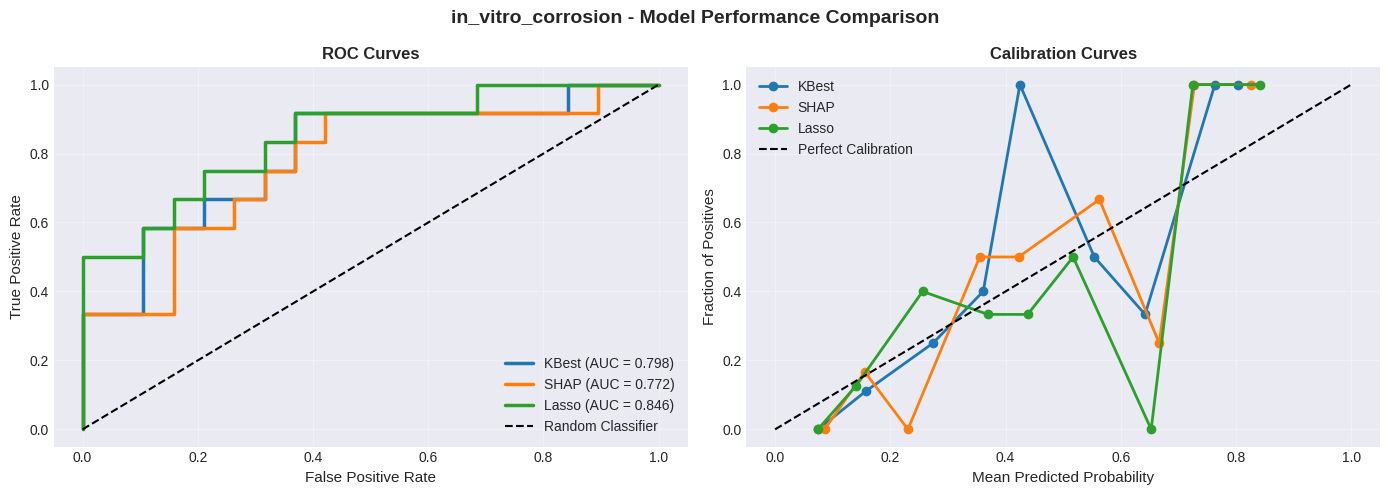

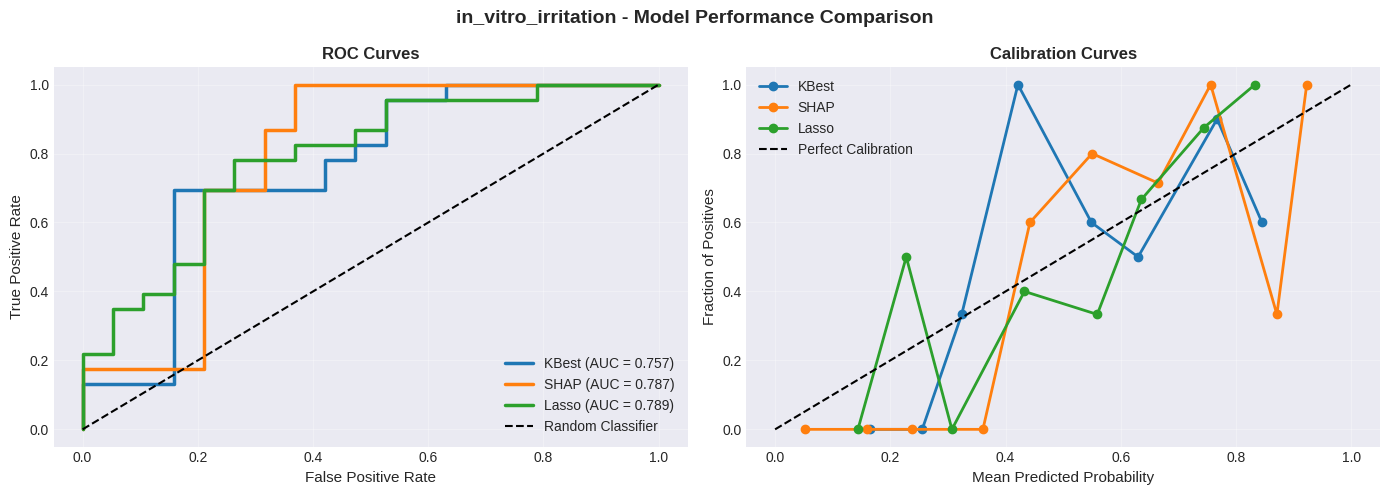

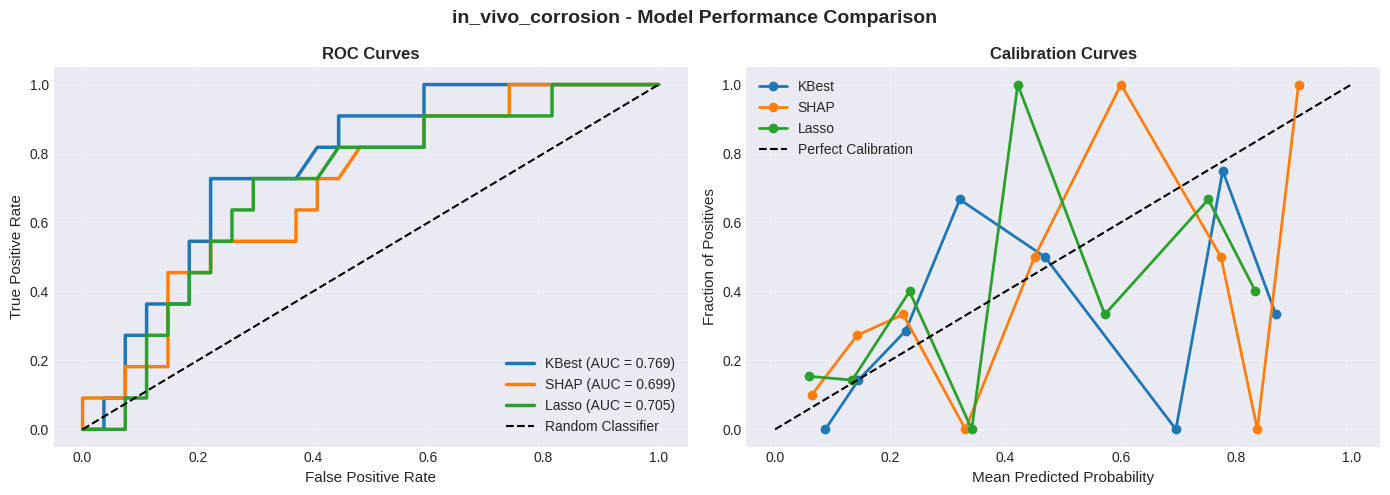

✓ ROC and calibration curves generated


In [14]:
for dataset_name in processed_data.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"{dataset_name} - Model Performance Comparison", fontsize=14, fontweight="bold"
    )

    colors = {"KBest": "#1f77b4", "SHAP": "#ff7f0e", "Lasso": "#2ca02c"}

    # ROC Curves
    for method in ["KBest", "SHAP", "Lasso"]:
        evals = evaluation_results[dataset_name][method]
        y_test = evals["y_test"]
        y_proba = evals["y_proba"]
        metrics = evals["metrics"]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = metrics["ROC-AUC"]

        ax1.plot(
            fpr,
            tpr,
            label=f"{method} (AUC = {roc_auc:.3f})",
            linewidth=2.5,
            color=colors[method],
        )

    ax1.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Classifier")
    ax1.set_xlabel("False Positive Rate", fontsize=11)
    ax1.set_ylabel("True Positive Rate", fontsize=11)
    ax1.set_title("ROC Curves", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=10, loc="lower right")
    ax1.grid(True, alpha=0.3)

    # Calibration Curves
    for method in ["KBest", "SHAP", "Lasso"]:
        evals = evaluation_results[dataset_name][method]
        y_test = evals["y_test"]
        y_proba = evals["y_proba"]

        prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
        ax2.plot(
            prob_pred,
            prob_true,
            marker="o",
            label=method,
            linewidth=2,
            markersize=6,
            color=colors[method],
        )

    ax2.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect Calibration")
    ax2.set_xlabel("Mean Predicted Probability", fontsize=11)
    ax2.set_ylabel("Fraction of Positives", fontsize=11)
    ax2.set_title("Calibration Curves", fontsize=12, fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✓ ROC and calibration curves generated")

## 11. Feature Importance Comparison



in_vitro_corrosion - Top Features by Selection Method


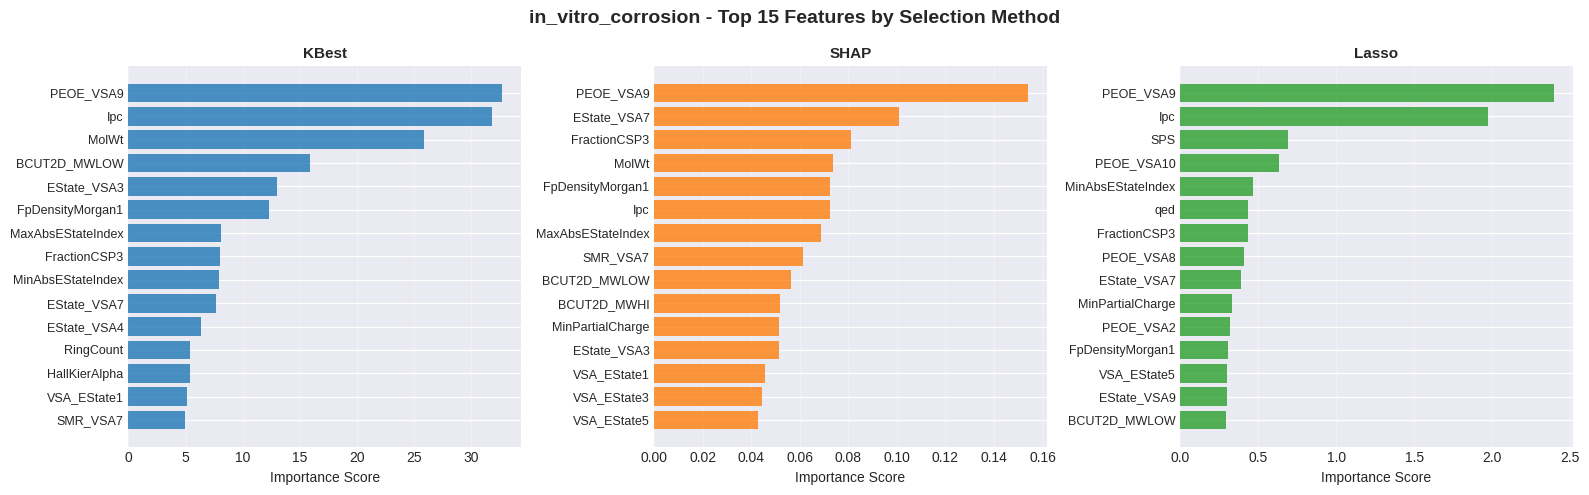



Top 10 KBest Features:
   1. PEOE_VSA9                      32.7561
   2. Ipc                            31.9061
   3. MolWt                          25.9176
   4. BCUT2D_MWLOW                   15.8870
   5. EState_VSA3                    13.0533
   6. FpDensityMorgan1               12.3183
   7. MaxAbsEStateIndex              8.1074
   8. FractionCSP3                   8.0201
   9. MinAbsEStateIndex              7.9685
  10. EState_VSA7                    7.6371

Top 10 SHAP Features:
   1. PEOE_VSA9                      0.1541
   2. EState_VSA7                    0.1009
   3. FractionCSP3                   0.0809
   4. MolWt                          0.0737
   5. FpDensityMorgan1               0.0725
   6. Ipc                            0.0725
   7. MaxAbsEStateIndex              0.0688
   8. SMR_VSA7                       0.0613
   9. BCUT2D_MWLOW                   0.0564
  10. BCUT2D_MWHI                    0.0518

Top 10 Lasso Features:
   1. PEOE_VSA9                      2.396

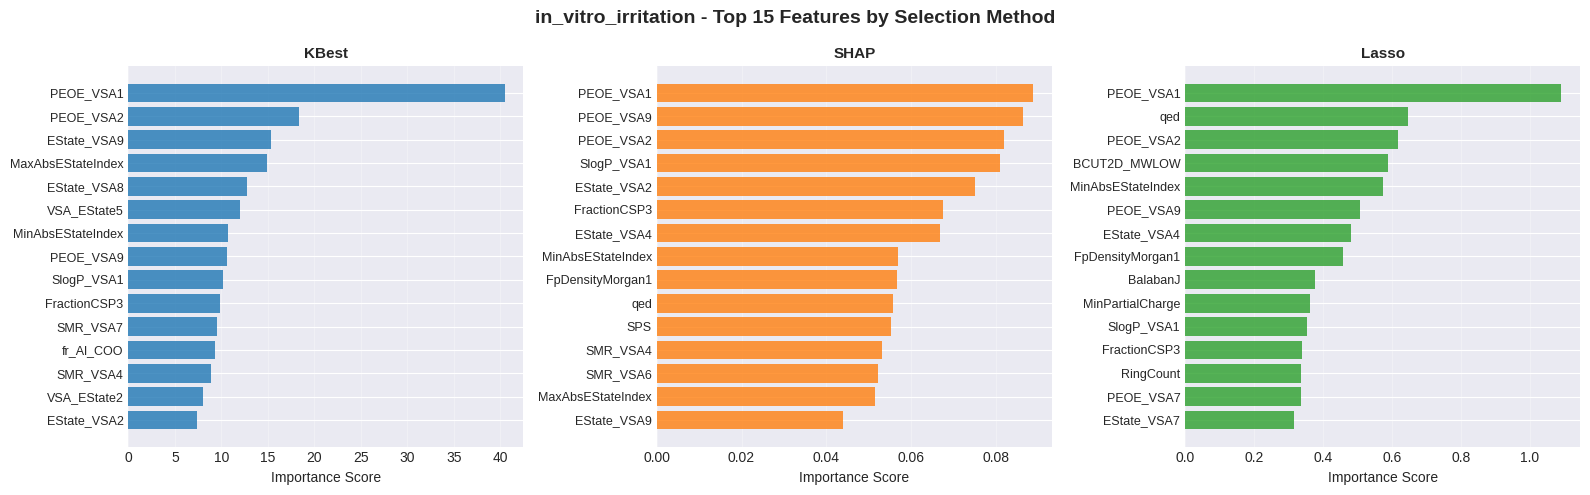



Top 10 KBest Features:
   1. PEOE_VSA1                      40.4653
   2. PEOE_VSA2                      18.3575
   3. EState_VSA9                    15.3805
   4. MaxAbsEStateIndex              14.9126
   5. EState_VSA8                    12.7437
   6. VSA_EState5                    12.0147
   7. MinAbsEStateIndex              10.6725
   8. PEOE_VSA9                      10.5670
   9. SlogP_VSA1                     10.2028
  10. FractionCSP3                   9.8673

Top 10 SHAP Features:
   1. PEOE_VSA1                      0.0888
   2. PEOE_VSA9                      0.0865
   3. PEOE_VSA2                      0.0820
   4. SlogP_VSA1                     0.0809
   5. EState_VSA2                    0.0750
   6. FractionCSP3                   0.0675
   7. EState_VSA4                    0.0668
   8. MinAbsEStateIndex              0.0569
   9. FpDensityMorgan1               0.0566
  10. qed                            0.0557

Top 10 Lasso Features:
   1. PEOE_VSA1                      1.

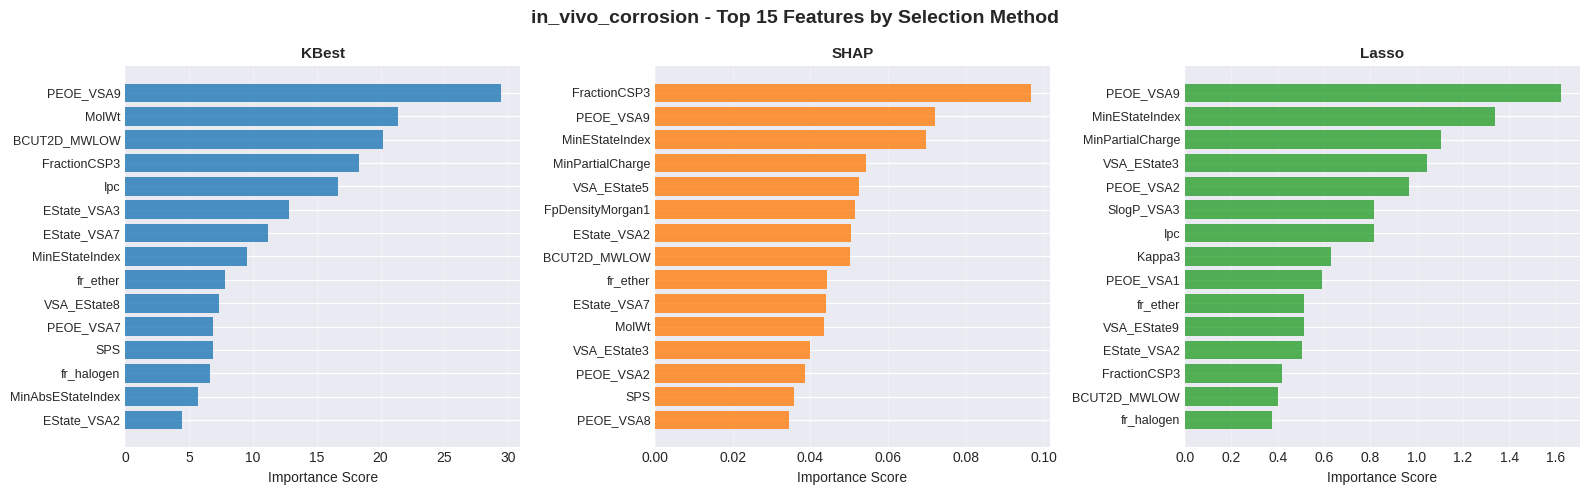



Top 10 KBest Features:
   1. PEOE_VSA9                      29.4643
   2. MolWt                          21.3689
   3. BCUT2D_MWLOW                   20.1646
   4. FractionCSP3                   18.3482
   5. Ipc                            16.6532
   6. EState_VSA3                    12.8711
   7. EState_VSA7                    11.2255
   8. MinEStateIndex                 9.5194
   9. fr_ether                       7.7984
  10. VSA_EState8                    7.3858

Top 10 SHAP Features:
   1. FractionCSP3                   0.0969
   2. PEOE_VSA9                      0.0720
   3. MinEStateIndex                 0.0698
   4. MinPartialCharge               0.0543
   5. VSA_EState5                    0.0525
   6. FpDensityMorgan1               0.0514
   7. EState_VSA2                    0.0503
   8. BCUT2D_MWLOW                   0.0502
   9. fr_ether                       0.0442
  10. EState_VSA7                    0.0440

Top 10 Lasso Features:
   1. PEOE_VSA9                      1.62

In [15]:
for dataset_name in processed_data.keys():
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Top Features by Selection Method")
    print(f"{'='*60}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"{dataset_name} - Top 15 Features by Selection Method",
        fontsize=14,
        fontweight="bold",
    )

    methods = ["KBest", "SHAP", "Lasso"]
    colors_methods = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    for idx, method in enumerate(methods):
        feature_scores = feature_results[dataset_name][method]["scores"]
        top_features = feature_scores.head(15)

        ax = axes[idx]
        y_pos = np.arange(len(top_features))
        ax.barh(y_pos, top_features.values, color=colors_methods[idx], alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_features.index, fontsize=9)
        ax.set_xlabel("Importance Score", fontsize=10)
        ax.set_title(f"{method}", fontsize=11, fontweight="bold")
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.show()

    # Print top 10 for each method
    print()
    for method in methods:
        feature_scores = feature_results[dataset_name][method]["scores"]
        top_10 = feature_scores.head(10)
        print(f"\nTop 10 {method} Features:")
        for rank, (feature, score) in enumerate(top_10.items(), 1):
            print(f"  {rank:2d}. {feature:30s} {score:.4f}")

## 12. Confusion Matrices


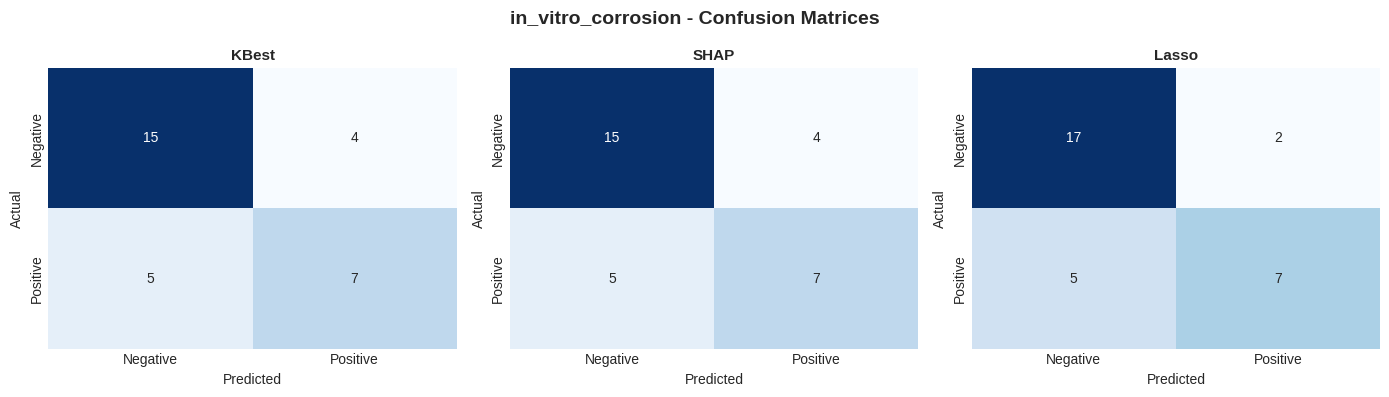

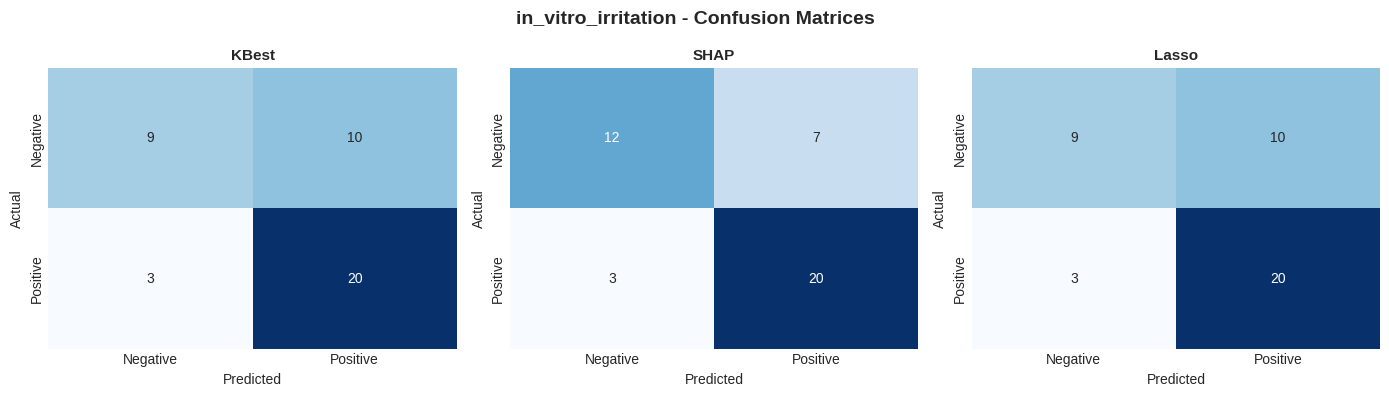

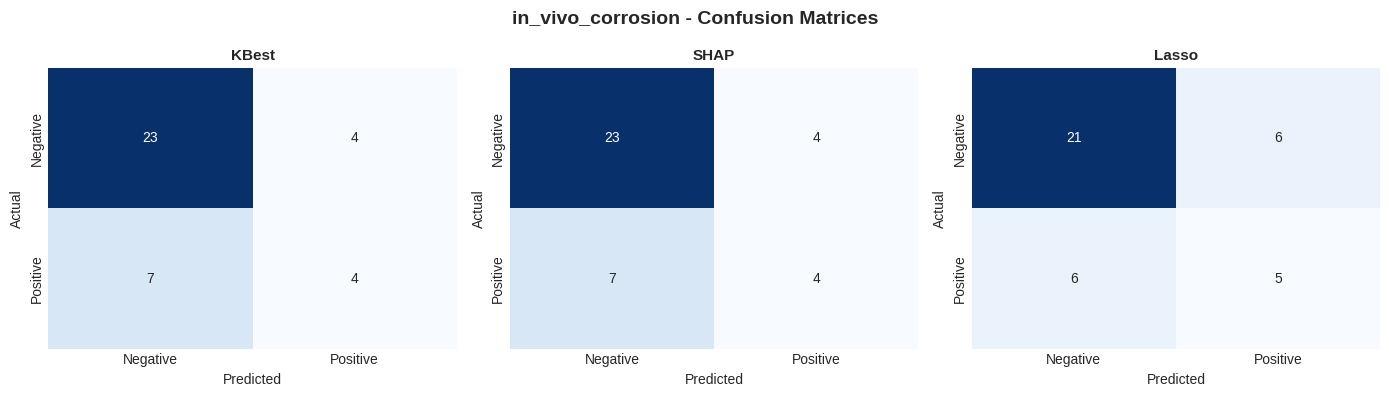

✓ Confusion matrix visualizations generated


In [16]:
for dataset_name in processed_data.keys():
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{dataset_name} - Confusion Matrices", fontsize=14, fontweight="bold")

    methods = ["KBest", "SHAP", "Lasso"]

    for idx, method in enumerate(methods):
        evals = evaluation_results[dataset_name][method]
        y_test = evals["y_test"]
        y_pred = evals["y_pred"]

        cm = confusion_matrix(y_test, y_pred)

        ax = axes[idx]
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax,
            cbar=False,
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
        )
        ax.set_ylabel("Actual", fontsize=10)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_title(f"{method}", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

print("✓ Confusion matrix visualizations generated")

## 13. Stakeholder Summary Report


In [17]:
print("\n" + "=" * 130)
print(" " * 40 + "FINAL STAKEHOLDER REPORT")
print("=" * 130)

METRIC_COLUMNS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]


def fmt_metric(value):
    if pd.isna(value):
        return "NA"
    return f"{value:.3f}"


def get_split_metrics(result):
    train_metrics = result.get("train_metrics", {})
    val_metrics = result.get("val_metrics", {})
    test_metrics = result.get("test_metrics", result.get("metrics", {}))
    return train_metrics, val_metrics, test_metrics


def unpack_optuna_params(params):
    return {
        "Kernel": params.get("kernel"),
        "C": params.get("C"),
        "Gamma Choice": params.get("gamma_choice"),
        "Gamma": params.get("gamma"),
        "Degree": params.get("degree"),
        "Coef0": params.get("coef0"),
        "Tol": params.get("tol"),
        "Max Iter": params.get("max_iter"),
        "Class Weight": params.get("class_weight"),
        "Shrinking": params.get("shrinking"),
    }


print("\nEXECUTIVE SUMMARY")
print("-" * 130)

best_models = {}

for dataset_name in processed_data.keys():
    print(f"\n{dataset_name}:")

    best_method = max(
        ["KBest", "SHAP", "Lasso"],
        key=lambda method: evaluation_results[dataset_name][method]
        .get("val_metrics", {})
        .get("ROC-AUC", -np.inf),
    )
    best_models[dataset_name] = best_method

    best_result = evaluation_results[dataset_name][best_method]
    train_metrics, val_metrics, test_metrics = get_split_metrics(best_result)

    print(f"  Recommended Descriptor Model (Validation-selected): {best_method}")
    print(
        f"    - OOF Train ROC-AUC: {fmt_metric(train_metrics.get('ROC-AUC', np.nan))}"
    )
    print(f"    - Validation ROC-AUC: {fmt_metric(val_metrics.get('ROC-AUC', np.nan))}")
    print(f"    - Test ROC-AUC: {fmt_metric(test_metrics.get('ROC-AUC', np.nan))}")
    print(f"    - Test Accuracy: {fmt_metric(test_metrics.get('Accuracy', np.nan))}")
    print(f"    - Test F1: {fmt_metric(test_metrics.get('F1', np.nan))}")
    print(
        f"    - Selected Features: {optimization_results[dataset_name][best_method]['best_k']}"
    )

    if dataset_name in fingerprint_variant_results:
        best_fp_variant, best_fp_data = max(
            fingerprint_variant_results[dataset_name].items(),
            key=lambda kv: kv[1].get("val_metrics", {}).get("ROC-AUC", -np.inf),
        )
        best_fp_val = best_fp_data.get("val_metrics", {})
        best_fp_test = best_fp_data.get("test_metrics", best_fp_data.get("metrics", {}))
        print(
            f"  Best Fingerprint Variant (Validation-selected): {best_fp_variant} "
            f"(Val ROC-AUC={fmt_metric(best_fp_val.get('ROC-AUC', np.nan))}, "
            f"Test ROC-AUC={fmt_metric(best_fp_test.get('ROC-AUC', np.nan))})"
        )

print("\n\nDETAILED COMPARISON - DESCRIPTOR MODELS")
print("-" * 130)

for dataset_name in processed_data.keys():
    print(f"\n{dataset_name}:")

    descriptor_rows = []
    for method in ["KBest", "SHAP", "Lasso"]:
        result = evaluation_results[dataset_name][method]
        train_metrics, val_metrics, test_metrics = get_split_metrics(result)
        opt_info = optimization_results[dataset_name][method]
        opt_params = unpack_optuna_params(opt_info["best_params"])

        row = {
            "Model Type": "Descriptor",
            "Model": method,
            "Features": opt_info["best_k"],
            "Validation ROC-AUC": fmt_metric(val_metrics.get("ROC-AUC", np.nan)),
        }

        for metric_name in METRIC_COLUMNS:
            row[f"OOF Train {metric_name}"] = fmt_metric(
                train_metrics.get(metric_name, np.nan)
            )
            row[f"Test {metric_name}"] = fmt_metric(
                test_metrics.get(metric_name, np.nan)
            )

        row.update(
            {
                "Kernel": opt_params["Kernel"],
                "C": opt_params["C"],
                "Gamma Choice": opt_params["Gamma Choice"],
                "Gamma": opt_params["Gamma"],
                "Degree": opt_params["Degree"],
                "Coef0": opt_params["Coef0"],
                "Tol": opt_params["Tol"],
                "Max Iter": opt_params["Max Iter"],
                "Class Weight": opt_params["Class Weight"],
                "Shrinking": opt_params["Shrinking"],
            }
        )
        descriptor_rows.append(row)

    descriptor_df = pd.DataFrame(descriptor_rows)
    print(descriptor_df.to_string(index=False))

print("\n\nDETAILED COMPARISON - FINGERPRINT VARIANTS (TEST RESULTS INCLUDED)")
print("-" * 130)

for dataset_name in processed_data.keys():
    if dataset_name not in fingerprint_variant_results:
        continue

    print(f"\n{dataset_name}:")

    fp_rows = []
    for variant_name, variant_result in fingerprint_variant_results[
        dataset_name
    ].items():
        train_metrics, val_metrics, test_metrics = get_split_metrics(variant_result)
        opt_params = unpack_optuna_params(variant_result.get("optuna_best_params", {}))

        row = {
            "Model Type": "FingerprintVariant",
            "Model": variant_name,
            "Base Descriptor Method": variant_result.get("method"),
            "Features": variant_result.get("n_features"),
            "Validation ROC-AUC": fmt_metric(val_metrics.get("ROC-AUC", np.nan)),
        }

        for metric_name in METRIC_COLUMNS:
            row[f"OOF Train {metric_name}"] = fmt_metric(
                train_metrics.get(metric_name, np.nan)
            )
            row[f"Test {metric_name}"] = fmt_metric(
                test_metrics.get(metric_name, np.nan)
            )

        row.update(
            {
                "Kernel": opt_params["Kernel"],
                "C": opt_params["C"],
                "Gamma Choice": opt_params["Gamma Choice"],
                "Gamma": opt_params["Gamma"],
                "Degree": opt_params["Degree"],
                "Coef0": opt_params["Coef0"],
                "Tol": opt_params["Tol"],
                "Max Iter": opt_params["Max Iter"],
                "Class Weight": opt_params["Class Weight"],
                "Shrinking": opt_params["Shrinking"],
            }
        )
        fp_rows.append(row)

    fp_df = pd.DataFrame(fp_rows)
    print(fp_df.to_string(index=False))

print("\n\nKEY RECOMMENDATIONS")
print("-" * 130)
print(
    """
1. FEATURE SELECTION:
   - All three methods (KBest, SHAP, Lasso) provide complementary insights.
   - KBest remains highly interpretable via F-score ranking.
   - SHAP provides model-agnostic feature importance.
   - Lasso emphasizes features with stronger discriminative signal.

2. MODEL SELECTION:
   - Select model family and variants using validation metrics only.
   - Report test metrics only after selection is frozen.

3. PERFORMANCE MONITORING:
   - Track OOF-train/validation/test metrics to detect overfitting early.
   - Prioritize validation for selection and test for final reporting.

4. DEPLOYMENT:
   - Persist Optuna-selected hyperparameters together with model artifacts.
   - Monitor data drift and retrain on a scheduled cadence.
"""
)

print("=" * 130)


                                        FINAL STAKEHOLDER REPORT

EXECUTIVE SUMMARY
----------------------------------------------------------------------------------------------------------------------------------

in_vitro_corrosion:
  Recommended Descriptor Model (Validation-selected): Lasso
    - OOF Train ROC-AUC: 0.860
    - Validation ROC-AUC: 0.893
    - Test ROC-AUC: 0.846
    - Test Accuracy: 0.774
    - Test F1: 0.667
    - Selected Features: 30
  Best Fingerprint Variant (Validation-selected): DescriptorsPlusMACCS (Val ROC-AUC=0.907, Test ROC-AUC=0.882)

in_vitro_irritation:
  Recommended Descriptor Model (Validation-selected): Lasso
    - OOF Train ROC-AUC: 0.852
    - Validation ROC-AUC: 0.930
    - Test ROC-AUC: 0.789
    - Test Accuracy: 0.690
    - Test F1: 0.755
    - Selected Features: 43
  Best Fingerprint Variant (Validation-selected): DescriptorsOnly (Val ROC-AUC=0.930, Test ROC-AUC=0.789)

in_vivo_corrosion:
  Recommended Descriptor Model (Validation-selected): 

## 14. Save Models and Results


In [18]:
print("\nSave Models and Results")
print("-" * 60)
print("Artifact export is executed in the next section (Section 15).")
print("This placeholder avoids duplicate stakeholder report output.")


Save Models and Results
------------------------------------------------------------
Artifact export is executed in the next section (Section 15).
This placeholder avoids duplicate stakeholder report output.


## 15. Save Artifacts and Next Steps


In [19]:
from pathlib import Path
import json

# Create output directory
output_dir = Path("svm_temp_results")
output_dir.mkdir(exist_ok=True)

for dataset_name in processed_data.keys():
    dataset_dir = output_dir / dataset_name.replace(" ", "_")
    dataset_dir.mkdir(exist_ok=True)

    print(f"\nSaving artifacts for {dataset_name}...")

    descriptor_preprocessor = processed_data[dataset_name].get(
        "descriptor_preprocessor"
    )
    if descriptor_preprocessor is not None:
        preprocessor_path = dataset_dir / "descriptor_preprocessor.joblib"
        dump(descriptor_preprocessor, preprocessor_path)
        print(f"  Saved: {preprocessor_path}")

    for method in ["KBest", "SHAP", "Lasso"]:
        model = final_models[dataset_name][method]
        model_path = dataset_dir / f"{method.lower()}_model.joblib"
        dump(model, model_path)
        print(f"  Saved: {model_path}")

    for method in ["KBest", "SHAP", "Lasso"]:
        features = evaluation_results[dataset_name][method]["feature_names"]
        features_path = dataset_dir / f"{method.lower()}_features.json"
        with open(features_path, "w") as f:
            json.dump(features, f, indent=2)
        print(f"  Saved: {features_path}")

    # Save baseline performance metrics (Train/Validation/Test + Optuna)
    metrics_data = {}
    for method in ["KBest", "SHAP", "Lasso"]:
        evals = evaluation_results[dataset_name][method]
        train_metrics = evals.get("train_metrics", {})
        val_metrics = evals.get("val_metrics", {})
        test_metrics = evals.get("test_metrics", evals.get("metrics", {}))

        metrics_data[method] = {
            "train_metrics": {k: float(v) for k, v in train_metrics.items()},
            "validation_metrics": {k: float(v) for k, v in val_metrics.items()},
            "test_metrics": {k: float(v) for k, v in test_metrics.items()},
            "metrics": {k: float(v) for k, v in test_metrics.items()},
            "optuna_best_params": optimization_results[dataset_name][method][
                "best_params"
            ],
        }

    metrics_path = dataset_dir / "performance_metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics_data, f, indent=2)
    print(f"  Saved: {metrics_path}")

    descriptor_export_dir = dataset_dir / "descriptor_exports"
    descriptor_export_dir.mkdir(exist_ok=True)

    descriptor_model_features = {
        "kbest": evaluation_results[dataset_name]["KBest"]["feature_names"],
        "shap": evaluation_results[dataset_name]["SHAP"]["feature_names"],
        "lasso": evaluation_results[dataset_name]["Lasso"]["feature_names"],
    }

    if (
        dataset_name in fingerprint_variant_results
        and "DescriptorsOnly" in fingerprint_variant_results[dataset_name]
    ):
        descriptor_model_features["descriptorsonly"] = fingerprint_variant_results[
            dataset_name
        ]["DescriptorsOnly"]["feature_names"]

    identifier_columns = processed_data[dataset_name].get("identifier_columns", [])
    metadata_by_split = {
        "train": processed_data[dataset_name].get("meta_train"),
        "val": processed_data[dataset_name].get("meta_val"),
        "test": processed_data[dataset_name].get("meta_test"),
    }

    for model_name, feature_columns in descriptor_model_features.items():
        for split_name, x_key, y_key in [
            ("train", "X_train", "y_train"),
            ("val", "X_val", "y_val"),
            ("test", "X_test", "y_test"),
        ]:
            x_split = processed_data[dataset_name][x_key]
            y_split = np.asarray(processed_data[dataset_name][y_key])

            available_feature_columns = [
                c for c in feature_columns if c in x_split.columns
            ]
            if not available_feature_columns:
                available_feature_columns = list(x_split.columns)

            export_df = x_split[available_feature_columns].copy()
            meta_split = metadata_by_split.get(split_name)
            if isinstance(meta_split, pd.DataFrame) and not meta_split.empty:
                available_id_cols = [
                    col for col in identifier_columns if col in meta_split.columns
                ]
                if "source_index" in meta_split.columns:
                    available_id_cols = ["source_index"] + available_id_cols
                if available_id_cols:
                    meta_export = meta_split.loc[export_df.index, available_id_cols]
                    export_df = pd.concat([meta_export, export_df], axis=1)

            export_df["target"] = y_split
            export_df = export_df.reset_index(drop=True)
            export_path = (
                descriptor_export_dir
                / f"{model_name}_{split_name}_selected_descriptors.csv"
            )
            export_df.to_csv(export_path, index=False)
            print(
                f"  Saved: {export_path} (rows={export_df.shape[0]}, cols={export_df.shape[1]})"
            )

    for split_name, x_key, y_key in [
        ("train", "X_train", "y_train"),
        ("val", "X_val", "y_val"),
        ("test", "X_test", "y_test"),
    ]:
        x_split = processed_data[dataset_name][x_key]
        y_split = np.asarray(processed_data[dataset_name][y_key])

        all_desc_df = x_split.copy()
        meta_split = metadata_by_split.get(split_name)
        if isinstance(meta_split, pd.DataFrame) and not meta_split.empty:
            available_id_cols = [
                col for col in identifier_columns if col in meta_split.columns
            ]
            if "source_index" in meta_split.columns:
                available_id_cols = ["source_index"] + available_id_cols
            if available_id_cols:
                meta_export = meta_split.loc[all_desc_df.index, available_id_cols]
                all_desc_df = pd.concat([meta_export, all_desc_df], axis=1)

        all_desc_df["target"] = y_split
        all_desc_df = all_desc_df.reset_index(drop=True)
        all_desc_path = descriptor_export_dir / f"all_descriptors_{split_name}.csv"
        all_desc_df.to_csv(all_desc_path, index=False)
        print(
            f"  Saved: {all_desc_path} (rows={all_desc_df.shape[0]}, cols={all_desc_df.shape[1]})"
        )

    if dataset_name in fingerprint_variant_models:
        fp_dir = dataset_dir / "fingerprint_variants"
        fp_dir.mkdir(exist_ok=True)

        fp_metrics = {}
        for variant_name, model in fingerprint_variant_models[dataset_name].items():
            safe_variant = variant_name.lower()
            model_path = fp_dir / f"{safe_variant}_model.joblib"
            dump(model, model_path)
            print(f"  Saved: {model_path}")

            variant_result = fingerprint_variant_results[dataset_name][variant_name]
            variant_features = variant_result["feature_names"]
            features_path = fp_dir / f"{safe_variant}_features.json"
            with open(features_path, "w") as f:
                json.dump(variant_features, f, indent=2)
            print(f"  Saved: {features_path}")

            train_metrics = variant_result.get("train_metrics", {})
            val_metrics = variant_result.get("val_metrics", {})
            test_metrics = variant_result.get(
                "test_metrics", variant_result.get("metrics", {})
            )

            fp_metrics[variant_name] = {
                "train_metrics": {k: float(v) for k, v in train_metrics.items()},
                "validation_metrics": {k: float(v) for k, v in val_metrics.items()},
                "test_metrics": {k: float(v) for k, v in test_metrics.items()},
                "metrics": {k: float(v) for k, v in test_metrics.items()},
                "n_features": int(variant_result.get("n_features", 0)),
                "added_fingerprint_family": variant_result.get(
                    "added_fingerprint_family"
                ),
                "added_fingerprint_bits": variant_result.get("added_fingerprint_bits"),
                "base_descriptor_method": variant_result.get("method"),
                "optuna_best_params": variant_result.get("optuna_best_params", {}),
            }

        fp_metrics_path = fp_dir / "fingerprint_variant_metrics.json"
        with open(fp_metrics_path, "w") as f:
            json.dump(fp_metrics, f, indent=2)
        print(f"  Saved: {fp_metrics_path}")

print(f"\nAll results saved to: {output_dir}")


Saving artifacts for in_vitro_corrosion...
  Saved: svm_temp_results/in_vitro_corrosion/descriptor_preprocessor.joblib
  Saved: svm_temp_results/in_vitro_corrosion/kbest_model.joblib
  Saved: svm_temp_results/in_vitro_corrosion/shap_model.joblib
  Saved: svm_temp_results/in_vitro_corrosion/lasso_model.joblib
  Saved: svm_temp_results/in_vitro_corrosion/kbest_features.json
  Saved: svm_temp_results/in_vitro_corrosion/shap_features.json
  Saved: svm_temp_results/in_vitro_corrosion/lasso_features.json
  Saved: svm_temp_results/in_vitro_corrosion/performance_metrics.json
  Saved: svm_temp_results/in_vitro_corrosion/descriptor_exports/kbest_train_selected_descriptors.csv (rows=96, cols=40)
  Saved: svm_temp_results/in_vitro_corrosion/descriptor_exports/kbest_val_selected_descriptors.csv (rows=24, cols=40)
  Saved: svm_temp_results/in_vitro_corrosion/descriptor_exports/kbest_test_selected_descriptors.csv (rows=31, cols=40)
  Saved: svm_temp_results/in_vitro_corrosion/descriptor_exports/shap